In [1]:
import subprocess, sys

def pip_install(*pkgs):
    """Install packages without force-upgrading the entire environment."""
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', '-q'] + list(pkgs)
    )

try:
    import torch, torchvision
    print(f'torch {torch.__version__} already present — skipping install.')
except ImportError:
    pip_install('torch', 'torchvision')

pip_install(
    'diffusers>=0.27.0',
    'accelerate>=0.26.0',
    'transformers>=4.38.0',
    'ruptures>=1.1.9',
    'scipy>=1.11.0',
    'matplotlib>=3.8.0',
    'tqdm>=4.66.0',
    'numpy>=1.24.0',
    'torchmetrics[image]>=1.3.0',
)
print('All dependencies installed.')


torch 2.10.0+cu128 already present — skipping install.
All dependencies installed.


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ruptures as rpt
from scipy.signal import welch
from tqdm import tqdm
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from diffusers import DDIMScheduler, UNet2DModel
from torchmetrics.image.fid import FrechetInceptionDistance
import warnings, random, copy, os

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'NumPy version: {np.__version__}')
print('Imports successful! ✅')


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
PyTorch version: 2.10.0+cu128
NumPy version: 2.0.2
Imports successful! ✅


In [3]:
CFG = dict(
    model_id       = 'google/ddpm-cifar10-32',
    T              = 100,
    n_calib        = 64,
    n_generate     = 512,
    n_real         = 512,
    batch_size     = 32,
    n_groups_pelt  = None,
    img_size       = 32,
)

unet = UNet2DModel.from_pretrained(CFG['model_id']).to(DEVICE)
unet.eval()

scheduler = DDIMScheduler.from_pretrained(CFG['model_id'])
scheduler.set_timesteps(CFG['T'])
timesteps = scheduler.timesteps

print(f'U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}')
print(f'Timesteps: {timesteps[:5]} ... {timesteps[-5:]}')


config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/143M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

U-Net parameters: 35,746,307
Timesteps: tensor([990, 980, 970, 960, 950]) ... tensor([40, 30, 20, 10,  0])


In [4]:
import torch.nn as nn

print("Target layers for quantization:")
print("-" * 60)

quant_layer_count = 0
for name, module in unet.named_modules():
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        extra_info = ""
        if isinstance(module, nn.Conv2d):
            extra_info = f"(in={module.in_channels}, out={module.out_channels}, k={module.kernel_size})"

        print(f"{name:<50} | {type(module).__name__:<10} {extra_info}")
        quant_layer_count += 1

print("-" * 60)
print(f"Total target layers: {quant_layer_count}")


Target layers for quantization:
------------------------------------------------------------
conv_in                                            | Conv2d     (in=3, out=128, k=(3, 3))
time_embedding.linear_1                            | Linear     
time_embedding.linear_2                            | Linear     
down_blocks.0.resnets.0.conv1                      | Conv2d     (in=128, out=128, k=(3, 3))
down_blocks.0.resnets.0.time_emb_proj              | Linear     
down_blocks.0.resnets.0.conv2                      | Conv2d     (in=128, out=128, k=(3, 3))
down_blocks.0.resnets.1.conv1                      | Conv2d     (in=128, out=128, k=(3, 3))
down_blocks.0.resnets.1.time_emb_proj              | Linear     
down_blocks.0.resnets.1.conv2                      | Conv2d     (in=128, out=128, k=(3, 3))
down_blocks.0.downsamplers.0.conv                  | Conv2d     (in=128, out=128, k=(3, 3))
down_blocks.1.attentions.0.to_q                    | Linear     
down_blocks.1.attentions.0.to_k 

Generating images...


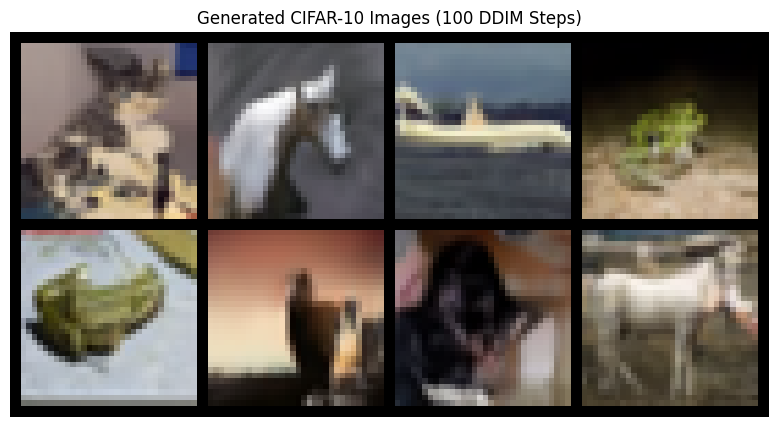

Fetching real image and applying forward noising...


100%|██████████| 170M/170M [08:30<00:00, 334kB/s]


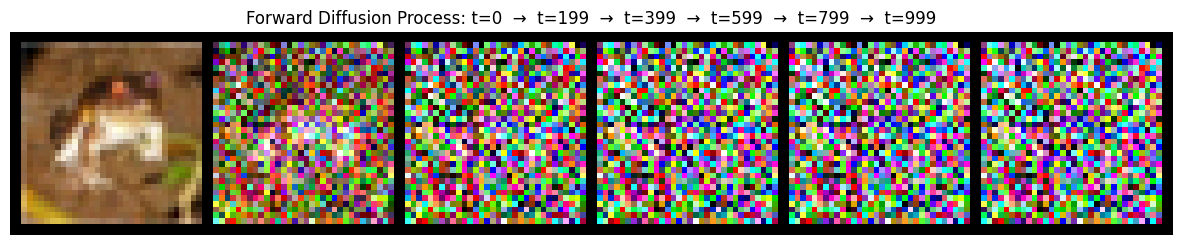

In [5]:
def show_generated_grid(unet, scheduler, num_images=8):
    print("Generating images...")
    unet.eval()

    x = torch.randn(num_images, 3, CFG['img_size'], CFG['img_size'], device=DEVICE)

    with torch.no_grad():
        for t in scheduler.timesteps:
            residual = unet(x, t).sample
            x = scheduler.step(residual, t, x).prev_sample

    x = (x / 2 + 0.5).clamp(0, 1)

    grid = torchvision.utils.make_grid(x, nrow=4).cpu().permute(1, 2, 0)

    plt.figure(figsize=(10, 5))
    plt.imshow(grid)
    plt.axis('off')
    plt.title(f"Generated CIFAR-10 Images ({CFG['T']} DDIM Steps)")
    plt.show()


def show_forward_noising_grid(scheduler):
    print("Fetching real image and applying forward noising...")

    transform = T.Compose([T.ToTensor(), T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

    x_0, _ = cifar[0]
    x_0 = x_0.unsqueeze(0).to(DEVICE)

    noise = torch.randn_like(x_0)

    max_t = scheduler.config.num_train_timesteps - 1
    display_steps = torch.linspace(0, max_t, 6, dtype=torch.long, device=DEVICE)

    noised_images = []

    for t in display_steps:
        x_t = scheduler.add_noise(x_0, noise, t)
        noised_images.append(x_t.squeeze(0))

    noised_tensor = torch.stack(noised_images)
    noised_tensor = (noised_tensor / 2 + 0.5).clamp(0, 1)

    grid = torchvision.utils.make_grid(noised_tensor, nrow=6).cpu().permute(1, 2, 0)

    plt.figure(figsize=(15, 3))
    plt.imshow(grid)
    plt.axis('off')

    step_labels = [f"t={t.item()}" for t in display_steps]
    plt.title(f"Forward Diffusion Process: { '  →  '.join(step_labels) }")
    plt.show()

show_generated_grid(unet, scheduler)
show_forward_noising_grid(scheduler)


In [6]:
high_res_acts = {}
_hook_handles   = []

target_layer = unet.down_blocks[0].resnets[0]
print('Hooking high-resolution module:', type(target_layer).__name__)

def _make_hook(t_val):
    def hook(module, inp, out):
        high_res_acts[int(t_val)] = out.detach().cpu().float()
    return hook

def register_hooks(t_val):
    """Register hook for current timestep, remove previous."""
    for h in _hook_handles:
        h.remove()
    _hook_handles.clear()

    h = target_layer.register_forward_hook(_make_hook(t_val))
    _hook_handles.append(h)

def clear_hooks():
    for h in _hook_handles:
        h.remove()
    _hook_handles.clear()


Hooking high-resolution module: ResnetBlock2D


In [7]:
@torch.no_grad()
def calibration_run(n_images=64):
    """Run DDIM denoising on n_images noise samples, collect high-res
    activations at every timestep. Returns dict {t: tensor(B,C,H,W)}."""
    high_res_acts.clear()

    x = torch.randn(n_images, 3, CFG['img_size'], CFG['img_size'], device=DEVICE)

    for t in tqdm(timesteps, desc='Calibration run'):
        register_hooks(t)
        t_batch = torch.full((n_images,), t, device=DEVICE, dtype=torch.long)

        noise_pred = unet(x, t_batch).sample

        x = scheduler.step(noise_pred, t, x).prev_sample

    clear_hooks()
    print(f'Collected activations at {len(high_res_acts)} timesteps')

    first_shape = next(iter(high_res_acts.values())).shape
    print(f'Activation shape per timestep: {first_shape}')

    return dict(high_res_acts)

calib_acts = calibration_run(CFG['n_calib'])


Calibration run: 100%|██████████| 100/100 [00:04<00:00, 20.21it/s]

Collected activations at 100 timesteps
Activation shape per timestep: torch.Size([64, 128, 32, 32])


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

def spectral_centroid_from_activation(act_tensor):
    """
    act_tensor: (B, C, H, W)
    """
    H, W = act_tensor.shape[-2:]

    fft2   = torch.fft.fft2(act_tensor, dim=(-2, -1))

    psd2d  = (fft2.abs() ** 2)

    psd2d_mean = psd2d.mean(dim=(0, 1))
    psd2d_mean = torch.fft.fftshift(psd2d_mean)

    cy, cx = H // 2, W // 2
    ys = torch.arange(H).float() - cy
    xs = torch.arange(W).float() - cx
    R  = torch.sqrt(ys[:, None]**2 + xs[None, :]**2).long()

    max_r = min(cy, cx)
    profile = torch.zeros(max_r + 1)

    for r in range(max_r + 1):
        mask = (R == r)
        if mask.any():
            profile[r] = psd2d_mean[mask].mean()

    freqs    = torch.arange(1, max_r + 1).float()
    profile_no_dc = profile[1:]

    centroid = (freqs * profile_no_dc).sum() / (profile_no_dc.sum() + 1e-8)

    return centroid.item(), profile.numpy(), psd2d_mean.cpu().numpy()

sorted_ts    = sorted(calib_acts.keys(), reverse=True)
centroids    = {}
psd_profiles = {}
psd_maps     = {}

for t in tqdm(sorted_ts, desc='Computing spectral metrics'):
    c, p, p2d = spectral_centroid_from_activation(calib_acts[t])
    centroids[t]    = c
    psd_profiles[t] = p
    psd_maps[t]     = p2d

centroid_seq = np.array([centroids[t] for t in sorted_ts])
print(f'Centroid range: [{centroid_seq.min():.3f}, {centroid_seq.max():.3f}]')


Computing spectral metrics: 100%|██████████| 100/100 [00:05<00:00, 16.89it/s]

Centroid range: [2.613, 7.507]


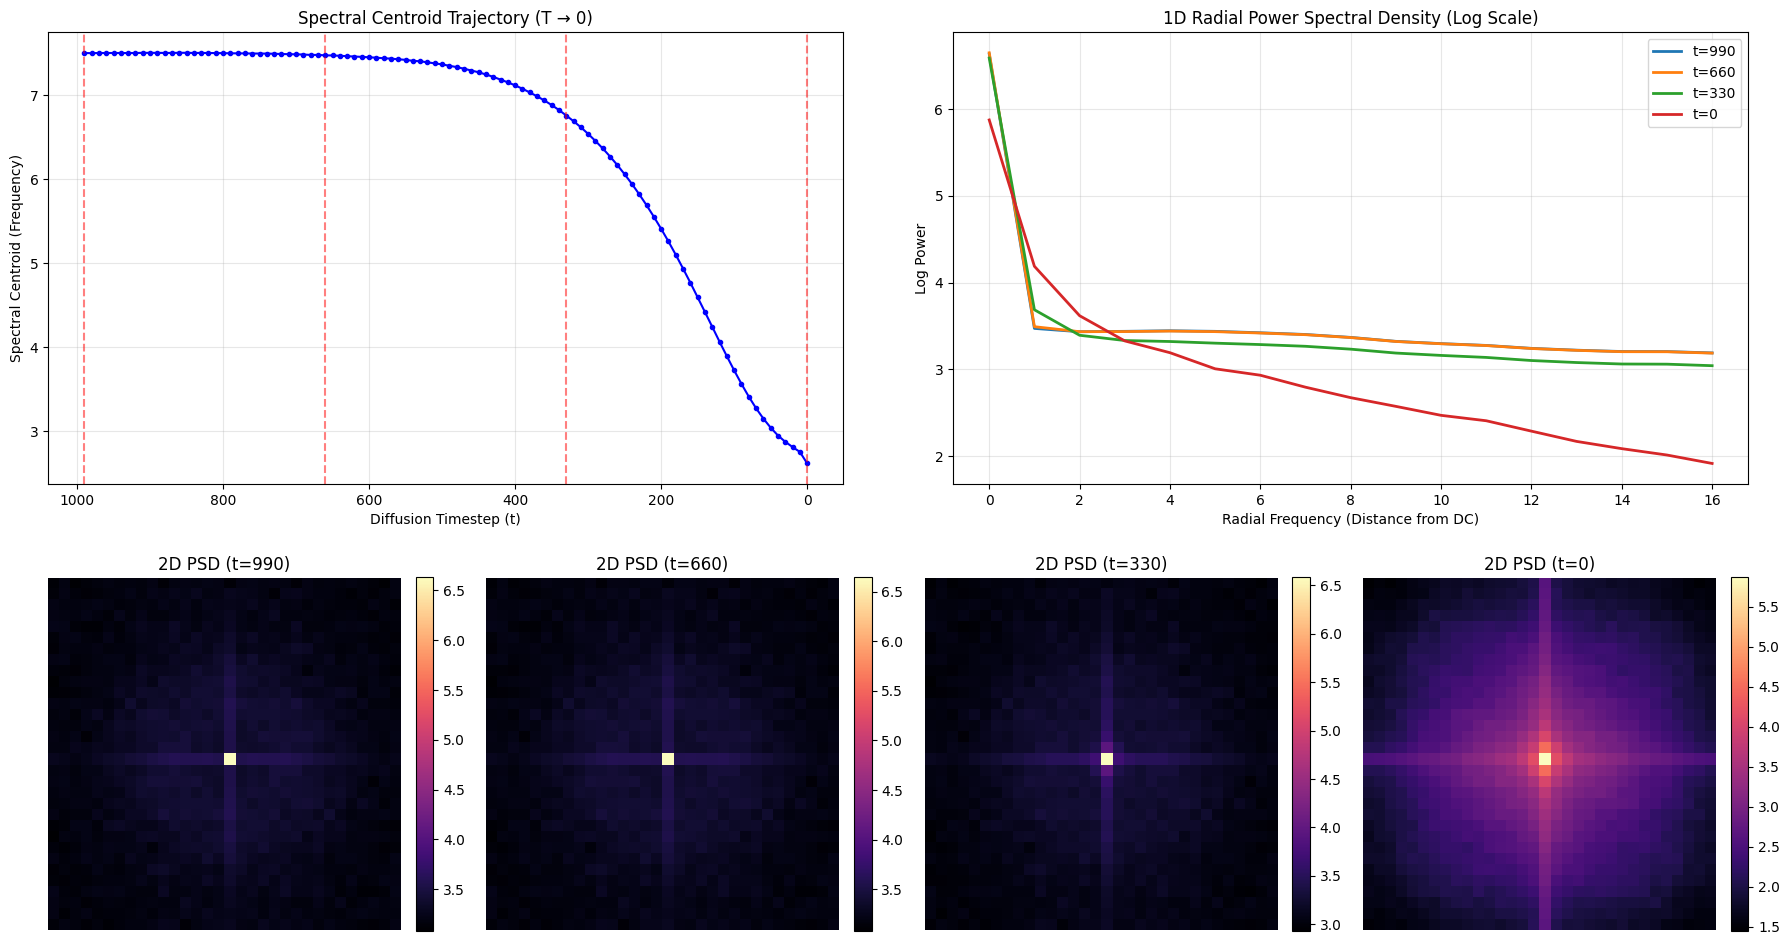

In [9]:
num_samples = 4
indices_to_plot = np.linspace(0, len(sorted_ts) - 1, num_samples, dtype=int)
sample_ts = [sorted_ts[i] for i in indices_to_plot]

fig = plt.figure(figsize=(18, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(sorted_ts, centroid_seq, marker='.', linestyle='-', color='b')
ax1.invert_xaxis()
for t in sample_ts:
    ax1.axvline(t, color='r', linestyle='--', alpha=0.5)
ax1.set_title("Spectral Centroid Trajectory (T → 0)")
ax1.set_xlabel("Diffusion Timestep (t)")
ax1.set_ylabel("Spectral Centroid (Frequency)")
ax1.grid(True, alpha=0.3)


ax2 = plt.subplot(2, 2, 2)
for t in sample_ts:
    profile = psd_profiles[t]
    freqs = np.arange(len(profile))
    ax2.plot(freqs, np.log10(profile + 1e-8), label=f"t={t}", linewidth=2)

ax2.set_title("1D Radial Power Spectral Density (Log Scale)")
ax2.set_xlabel("Radial Frequency (Distance from DC)")
ax2.set_ylabel("Log Power")
ax2.legend()
ax2.grid(True, alpha=0.3)


for idx, t in enumerate(sample_ts):
    ax = plt.subplot(2, num_samples, num_samples + idx + 1)
    p2d = psd_maps[t]

    p2d_log = np.log10(p2d + 1e-8)

    im = ax.imshow(p2d_log, cmap='magma', interpolation='nearest')
    ax.set_title(f"2D PSD (t={t})")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [10]:
def run_pelt(signal, max_groups=8):
    """
    Run Dynamic Programming (Dynp) with BIC penalty selection.
    Dynp gives the globally optimal segmentation for a fixed number of
    breakpoints — correct for an exhaustive BIC sweep.
    Returns breakpoint indices into `signal`.
    """
    signal_2d = signal.reshape(-1, 1)

    best_bic  = np.inf
    best_bkps = None
    best_n    = None
    n = len(signal)

    algo = rpt.Dynp(model='rbf', min_size=3, jump=1).fit(signal_2d)

    for n_bkps in range(1, max_groups):
        try:
            bkps = algo.predict(n_bkps=n_bkps)
        except Exception:
            continue

        segments = np.split(signal, bkps[:-1])
        rss = sum(((s - s.mean())**2).sum() for s in segments if len(s) > 0)
        k   = n_bkps + 1
        bic = n * np.log(max(rss / n, 1e-8)) + k * np.log(n)

        if bic < best_bic:
            best_bic  = bic
            best_bkps = bkps
            best_n    = n_bkps

    if best_bkps is None:
        best_bkps = [len(signal)]
        best_n    = 0

    print(f'Selected {best_n} breakpoints (BIC={best_bic:.2f})')
    return best_bkps

pelt_bkps = run_pelt(centroid_seq)

def bkps_to_timestep_groups(bkps, sorted_ts):
    """Returns list of (t_high, t_low) tuples in timestep space."""
    if bkps is None:
        bkps = [len(sorted_ts)]
    boundaries = [0] + bkps
    groups = []
    for i in range(len(boundaries) - 1):
        seg_ts = sorted_ts[boundaries[i]:boundaries[i+1]]
        if len(seg_ts) > 0:
            groups.append((max(seg_ts), min(seg_ts)))
    return groups

spectral_groups = bkps_to_timestep_groups(pelt_bkps, sorted_ts)
print('\nSpectral groups (t_high → t_low):')
for i, (hi, lo) in enumerate(spectral_groups):
    n_actual = sum(1 for t in sorted_ts if lo <= t <= hi)
    print(f'  Group {i+1}: t ∈ [{lo}, {hi}]  ({n_actual} DDIM steps)')

n_groups = len(spectral_groups)
if n_groups > 0:
    uniform_bkps_idx = list(np.round(np.linspace(0, len(sorted_ts), n_groups + 1)).astype(int))
    uniform_groups   = []
    for i in range(n_groups):
        seg = sorted_ts[uniform_bkps_idx[i]:uniform_bkps_idx[i+1]]
        if len(seg) > 0:
            uniform_groups.append((max(seg), min(seg)))
    print('\nUniform groups (t_high → t_low):')
    for i, (hi, lo) in enumerate(uniform_groups):
        n_actual = sum(1 for t in sorted_ts if lo <= t <= hi)
        print(f'  Group {i+1}: t ∈ [{lo}, {hi}]  ({n_actual} DDIM steps)')
else:
    uniform_bkps_idx = [0, len(sorted_ts)]
    uniform_groups   = [(max(sorted_ts), min(sorted_ts))]
    n_groups         = 1
    print('\nNo spectral breakpoints found — using single group.')


Selected 7 breakpoints (BIC=-371.25)

Spectral groups (t_high → t_low):
  Group 1: t ∈ [450, 990]  (55 DDIM steps)
  Group 2: t ∈ [340, 440]  (11 DDIM steps)
  Group 3: t ∈ [270, 330]  (7 DDIM steps)
  Group 4: t ∈ [210, 260]  (6 DDIM steps)
  Group 5: t ∈ [160, 200]  (5 DDIM steps)
  Group 6: t ∈ [120, 150]  (4 DDIM steps)
  Group 7: t ∈ [70, 110]  (5 DDIM steps)
  Group 8: t ∈ [0, 60]  (7 DDIM steps)

Uniform groups (t_high → t_low):
  Group 1: t ∈ [880, 990]  (12 DDIM steps)
  Group 2: t ∈ [750, 870]  (13 DDIM steps)
  Group 3: t ∈ [620, 740]  (13 DDIM steps)
  Group 4: t ∈ [500, 610]  (12 DDIM steps)
  Group 5: t ∈ [380, 490]  (12 DDIM steps)
  Group 6: t ∈ [250, 370]  (13 DDIM steps)
  Group 7: t ∈ [120, 240]  (13 DDIM steps)
  Group 8: t ∈ [0, 110]  (12 DDIM steps)


Generating image and capturing 8 group boundaries for: Spectral Groups (Dynp/PELT)


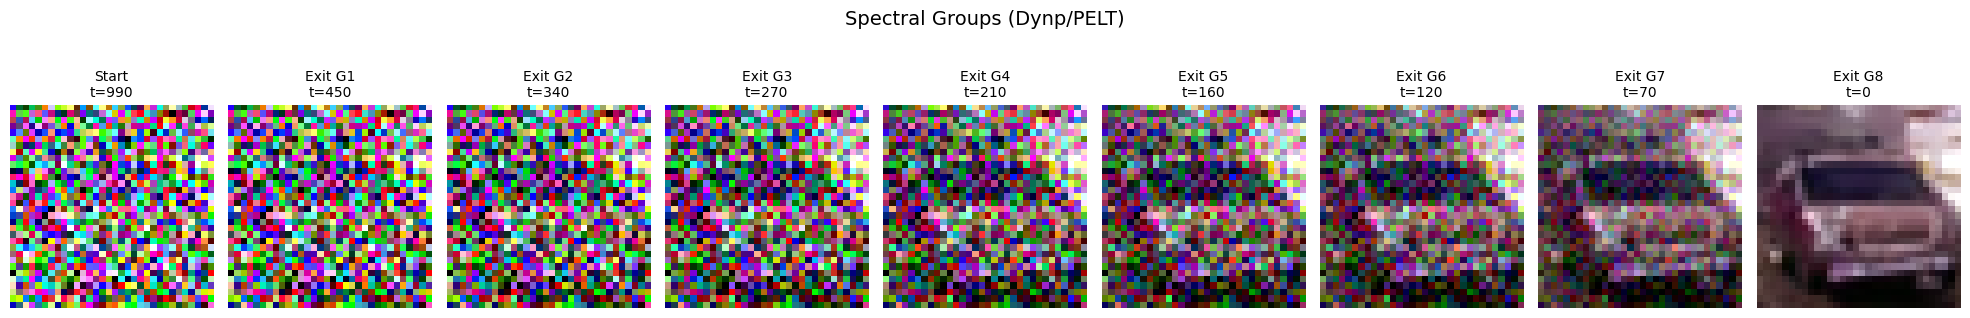

Generating image and capturing 8 group boundaries for: Uniform Groups (Baseline)


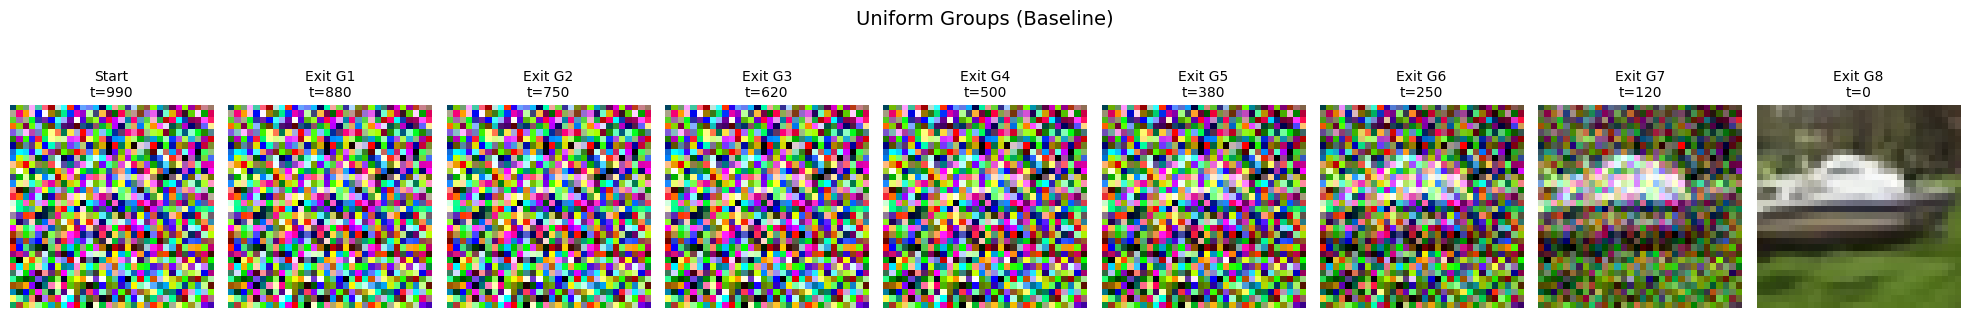

In [11]:
import torch
import torchvision
import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_dynamic_groups(unet, scheduler, groups, title="Image State at Group Boundaries", img_size=32, device='cuda'):
    print(f"Generating image and capturing {len(groups)} group boundaries for: {title}")
    unet.eval()

    targets = [lo for (hi, lo) in groups]

    x = torch.randn(1, 3, img_size, img_size, device=device)

    captured_images = []
    labels = []

    start_t = groups[0][0]
    captured_images.append((x.clone() / 2 + 0.5).clamp(0, 1).squeeze(0).cpu())
    labels.append(f"Start\nt={start_t}")

    for t in scheduler.timesteps:
        t_val = t.item()

        residual = unet(x, t).sample
        x = scheduler.step(residual, t, x).prev_sample

        if len(targets) > 0 and t_val <= targets[0]:
            just_exited = targets.pop(0)

            img_to_save = (x.clone() / 2 + 0.5).clamp(0, 1)
            captured_images.append(img_to_save.squeeze(0).cpu())

            g_num = len(groups) - len(targets)
            labels.append(f"Exit G{g_num}\nt={just_exited}")

    fig, axes = plt.subplots(1, len(captured_images), figsize=(2.2 * len(captured_images), 3))

    for i, (img, label) in enumerate(zip(captured_images, labels)):
        ax = axes[i]
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(label, fontsize=10)
        ax.axis('off')

    plt.suptitle(title, fontsize=14, y=1.1)
    plt.tight_layout()
    plt.show()

visualize_dynamic_groups(unet, scheduler, spectral_groups, title="Spectral Groups (Dynp/PELT)")
visualize_dynamic_groups(unet, scheduler, uniform_groups, title="Uniform Groups (Baseline)")


In [12]:
ACT_PERCENTILE = 99.99
W_PERCENTILE   = 99.9

def compute_weight_scale(w, n_bits):
    """
    Per-output-channel scale for weights.
    W8: absmax -- 8-bit has enough levels that outliers rarely hurt.
    W4: 99.9th-percentile clip -- absmax wastes most of the 15 quantisation
        levels on rare spikes, causing massive MSE for all other weights.
    """
    w_flat = w.abs().flatten(start_dim=1)
    if n_bits >= 8:
        scale = w_flat.amax(dim=1, keepdim=True)
    else:

        scale = torch.quantile(w_flat.float(), W_PERCENTILE / 100.0,
                               dim=1, keepdim=True)

    extra = [1] * (w.dim() - 2)
    scale = scale.view(w.shape[0], 1, *extra)
    return scale.clamp(min=1e-8)


def compute_activation_scale(act_list, n_bits, max_elements=1_000_000):
    """
    Computes a stable 99.99th-percentile activation scale.
    Uniformly subsamples the aggregate distribution to prevent OOM while
    preserving the true statistical shape.
    """
    all_vals = torch.cat([a.float().abs().flatten() for a in act_list])
    if all_vals.numel() > max_elements:
        indices  = torch.randint(0, all_vals.numel(), (max_elements,))
        all_vals = all_vals[indices]
    scale = torch.quantile(all_vals.to(DEVICE), ACT_PERCENTILE / 100.0).cpu()
    return scale.clamp(min=1e-8)


def fake_quant(x, scale, n_bits):
    """Symmetric fake-quantization with a pre-computed scale."""
    qmax = 2 ** (n_bits - 1) - 1
    x_q  = (x / scale * qmax).round().clamp(-qmax, qmax)
    return x_q / qmax * scale

print('Quantization helpers ready (percentile weight scale for W4).')


Quantization helpers ready (percentile weight scale for W4).


In [13]:
class FakeQuantLinear(nn.Module):
    def __init__(self, linear, w_bits=8, a_bits=8,
                 group_scales=None, group_ranges=None,
                 householder_vectors=None):
        """
        group_scales : list[float], one activation scale per timestep group
        group_ranges : list[(t_hi, t_lo)], parallel to group_scales
        householder_vectors : optional tensor/list with shape (G, k, in_features).
            If provided, activation quantization uses the mathematically safe
            sandwich H_t^T Q(H_t x), so the layer is unchanged when Q is identity.
        """
        super().__init__()
        self.w_bits = w_bits
        self.a_bits = a_bits
        self.weight = nn.Parameter(linear.weight.data.clone())
        self.bias   = (nn.Parameter(linear.bias.data.clone())
                       if linear.bias is not None else None)
        self.register_buffer('w_scale',
                             compute_weight_scale(linear.weight.data, w_bits))
        if group_scales is not None and group_ranges is not None:
            assert len(group_scales) == len(group_ranges)
            self.register_buffer('group_act_scales',
                                 torch.tensor(group_scales, dtype=torch.float32))
            self.group_ranges = group_ranges
        else:
            fallback = float(linear.weight.data.abs().max().clamp(min=1e-8))
            self.register_buffer('group_act_scales', torch.tensor([fallback]))
            self.group_ranges = [(int(1e9), 0)]

        if householder_vectors is not None:
            hh = torch.as_tensor(householder_vectors, dtype=torch.float32)
            assert hh.dim() == 3 and hh.shape[-1] == linear.in_features, \
                f'Householder tensor must be (G,k,{linear.in_features}), got {tuple(hh.shape)}'
            self.register_buffer('householder_vectors', hh)
        else:
            self.householder_vectors = None
        self.current_t = None

    def _get_group_idx(self):
        if self.current_t is None:
            return 0
        for i, (t_hi, t_lo) in enumerate(self.group_ranges):
            if t_lo <= self.current_t <= t_hi:
                return i
        return 0

    def _get_act_scale(self):
        return self.group_act_scales[self._get_group_idx()]

    def _householder_lastdim(self, x, vectors, reverse=False):
        """Apply product of Householder reflections along the last dim."""
        if vectors is None or vectors.numel() == 0:
            return x
        order = range(vectors.shape[0]-1, -1, -1) if reverse else range(vectors.shape[0])
        y = x
        for i in order:
            v = vectors[i].to(device=x.device, dtype=x.dtype)
            v = v / (v.norm() + 1e-8)
            dot = (y * v).sum(dim=-1, keepdim=True)
            y = y - 2.0 * dot * v
        return y

    def _quantize_activation(self, x):
        scale = self._get_act_scale().to(x.device)
        if self.householder_vectors is None:
            return fake_quant(x, scale, self.a_bits)
        gi = self._get_group_idx()
        vecs = self.householder_vectors[gi]

        z   = self._householder_lastdim(x, vecs, reverse=False)
        z_q = fake_quant(z, scale, self.a_bits)
        return self._householder_lastdim(z_q, vecs, reverse=True)

    def forward(self, x):
        w_q = fake_quant(self.weight, self.w_scale.to(x.device), self.w_bits)
        x_q = self._quantize_activation(x)
        return nn.functional.linear(x_q, w_q, self.bias)


class FakeQuantConv2d(nn.Module):
    def __init__(self, conv, w_bits=8, a_bits=8,
                 group_scales=None, group_ranges=None,
                 householder_vectors=None):
        super().__init__()
        self.w_bits   = w_bits
        self.a_bits   = a_bits
        self.weight = nn.Parameter(conv.weight.data.clone())
        self.bias   = (nn.Parameter(conv.bias.data.clone())
                       if conv.bias is not None else None)
        self.stride   = conv.stride
        self.padding  = conv.padding
        self.dilation = conv.dilation
        self.groups   = conv.groups
        self.in_channels = conv.in_channels
        self.register_buffer('w_scale',
                             compute_weight_scale(conv.weight.data, w_bits))
        if group_scales is not None and group_ranges is not None:
            assert len(group_scales) == len(group_ranges)
            self.register_buffer('group_act_scales',
                                 torch.tensor(group_scales, dtype=torch.float32))
            self.group_ranges = group_ranges
        else:
            fallback = float(conv.weight.data.abs().max().clamp(min=1e-8))
            self.register_buffer('group_act_scales', torch.tensor([fallback]))
            self.group_ranges = [(int(1e9), 0)]

        if householder_vectors is not None:
            hh = torch.as_tensor(householder_vectors, dtype=torch.float32)
            assert hh.dim() == 3 and hh.shape[-1] == conv.in_channels, \
                f'Householder tensor must be (G,k,{conv.in_channels}), got {tuple(hh.shape)}'
            self.register_buffer('householder_vectors', hh)
        else:
            self.householder_vectors = None
        self.current_t = None

    def _get_group_idx(self):
        if self.current_t is None:
            return 0
        for i, (t_hi, t_lo) in enumerate(self.group_ranges):
            if t_lo <= self.current_t <= t_hi:
                return i
        return 0

    def _get_act_scale(self):
        return self.group_act_scales[self._get_group_idx()]

    def _householder_channel(self, x, vectors, reverse=False):
        """Apply product of Householder reflections along channel dim of BCHW."""
        if vectors is None or vectors.numel() == 0:
            return x
        order = range(vectors.shape[0]-1, -1, -1) if reverse else range(vectors.shape[0])
        y = x
        for i in order:
            v = vectors[i].to(device=x.device, dtype=x.dtype)
            v = v / (v.norm() + 1e-8)
            v4 = v.view(1, -1, 1, 1)
            dot = (y * v4).sum(dim=1, keepdim=True)
            y = y - 2.0 * dot * v4
        return y

    def _quantize_activation(self, x):
        scale = self._get_act_scale().to(x.device)
        if self.householder_vectors is None:
            return fake_quant(x, scale, self.a_bits)
        gi = self._get_group_idx()
        vecs = self.householder_vectors[gi]

        z   = self._householder_channel(x, vecs, reverse=False)
        z_q = fake_quant(z, scale, self.a_bits)
        return self._householder_channel(z_q, vecs, reverse=True)

    def forward(self, x):
        w_q = fake_quant(self.weight, self.w_scale.to(x.device), self.w_bits)
        x_q = self._quantize_activation(x)
        return nn.functional.conv2d(
            x_q, w_q, self.bias,
            self.stride, self.padding, self.dilation, self.groups)


def set_timestep(model, t):
    """Broadcast current timestep to all fake-quant layers before unet()."""
    t = int(t)
    for module in model.modules():
        if isinstance(module, (FakeQuantLinear, FakeQuantConv2d)):
            module.current_t = t

print('FakeQuant wrapper classes ready, including optional Householder activation-quantization sandwich.')


FakeQuant wrapper classes ready, including optional Householder activation-quantization sandwich.


In [14]:
SENSITIVE_W8 = {'time', 'conv_out', 'conv_in', 'time_proj', 'shortcut'}
SENSITIVE_W4 = SENSITIVE_W8 | {'attn', 'proj_attn', 'to_q', 'to_k',
                                'to_v', 'to_out', 'norm', 'group_norm'}

def _is_sensitive(name, w_bits):
    keywords = SENSITIVE_W4 if w_bits <= 4 else SENSITIVE_W8
    return any(k in name for k in keywords)


def compute_group_scales(model, groups, w_bits=8, a_bits=8,
                         n_batches=16, batch_size=32):
    """Collect per-layer activation statistics for each timestep group."""
    model.eval()
    print(f'  [compute_group_scales] w_bits={w_bits}, a_bits={a_bits}')
    ds = torchvision.datasets.CIFAR10(
        root='/tmp/cifar10', train=True, download=False,
        transform=T.Compose([
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]))
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()
    group_scales    = {}
    hook_handles    = []
    current_acts    = {}
    MAX_ELEMS       = 1_000_000
    elems_per_batch = MAX_ELEMS // n_batches

    def make_hook(name):
        def hook(module, inp, out):
            vals = inp[0].detach().float().abs().flatten()
            if vals.numel() > elems_per_batch:
                idx  = torch.randint(0, vals.numel(), (elems_per_batch,),
                                     device=vals.device)
                vals = vals[idx]
            current_acts.setdefault(name, []).append(vals.cpu())
        return hook

    for name, module in model.named_modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            hook_handles.append(module.register_forward_hook(make_hook(name)))

    try:
        for t_hi, t_lo in tqdm(groups, desc='Computing group scales'):
            current_acts.clear()
            torch.cuda.empty_cache()
            group_ddim_ts = [int(t) for t in timesteps.tolist() if t_lo <= int(t) <= t_hi]
            if not group_ddim_ts:
                group_ddim_ts = [int((t_hi + t_lo) // 2)]
            rand_idx = torch.randint(0, len(group_ddim_ts), (n_batches,))
            group_ts = torch.tensor(
                [group_ddim_ts[i] for i in rand_idx], dtype=torch.long)
            with torch.no_grad():
                for t in group_ts:
                    idx     = torch.randint(0, len(ds), (batch_size,))
                    x_clean = torch.stack([ds[i][0] for i in idx]).to(DEVICE)
                    noise   = torch.randn_like(x_clean)
                    t_batch = torch.full((batch_size,), int(t),
                                        device=DEVICE, dtype=torch.long)
                    x_noisy = scheduler.add_noise(x_clean, noise, t_batch)
                    model(x_noisy, t_batch)
            for name, act_list in current_acts.items():
                scale = compute_activation_scale(act_list, a_bits).item()
                group_scales.setdefault(name, []).append(
                    (scale, int(t_hi), int(t_lo)))
            current_acts.clear()
            torch.cuda.empty_cache()
    finally:
        for h in hook_handles:
            h.remove()
    return group_scales


def apply_fake_quant_from_group_scales(model, group_scales, groups,
                                        w_bits=8, a_bits=8,
                                        householder_vectors=None):
    """
    Deep-copy model and replace every non-sensitive Linear/Conv2d with a
    timestep-aware fake-quant wrapper.

    householder_vectors: optional dict {layer_name: tensor(G,k,in_channels)}.
    If a layer has an entry, activation quantization becomes H_t^T Q(H_t x).
    This is the corrected version of timestep-dependent rotation: the inverse
    rotation is applied before the quantized matmul/conv, so full precision
    equivalence is preserved when Q is identity.
    """
    model = copy.deepcopy(model)
    householder_vectors = householder_vectors or {}
    for name, module in list(model.named_modules()):
        if _is_sensitive(name, w_bits):
            continue
        if not isinstance(module, (nn.Linear, nn.Conv2d)):
            continue
        parent = model
        parts  = name.split('.')
        for p in parts[:-1]:
            parent = getattr(parent, p)
        leaf = parts[-1]
        scales_for_layer = group_scales.get(name)
        if scales_for_layer is not None:
            scales = [s        for s, _, _  in scales_for_layer]
            ranges = [(hi, lo) for _, hi, lo in scales_for_layer]
        else:
            fallback = float(module.weight.data.abs().max().clamp(min=1e-8))
            scales   = [fallback] * len(groups)
            ranges   = list(groups)
        Wrapper = (FakeQuantLinear if isinstance(module, nn.Linear)
                   else FakeQuantConv2d)
        hh = householder_vectors.get(name, None)
        setattr(parent, leaf,
                Wrapper(module, w_bits, a_bits,
                        group_scales=scales, group_ranges=ranges,
                        householder_vectors=hh))
    n_quant = sum(1 for m in model.modules()
                  if isinstance(m, (FakeQuantLinear, FakeQuantConv2d)))
    n_hh = sum(1 for m in model.modules()
               if isinstance(m, (FakeQuantLinear, FakeQuantConv2d)) and
               getattr(m, 'householder_vectors', None) is not None)
    print(f'  Quantized {n_quant} layers  (w_bits={w_bits}, a_bits={a_bits}); Householder on {n_hh} layers')
    return model


print('Quantization pipeline ready, with optional Householder rotations.')


Quantization pipeline ready, with optional Householder rotations.


In [15]:
def _module_in_dim(module):
    if isinstance(module, nn.Conv2d):
        return module.in_channels
    if isinstance(module, nn.Linear):
        return module.in_features
    return None


def get_quantizable_layer_names(model, w_bits=8, max_layers=None):
    """Layer list that matches apply_fake_quant_from_group_scales exclusions."""
    names = []
    for name, module in model.named_modules():
        if _is_sensitive(name, w_bits):
            continue
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            names.append(name)
    if max_layers is not None:
        names = names[:max_layers]
    return names


def _activation_to_vectors(x, module, max_vectors=8192):
    """Convert layer input activation into channel vectors for Householder fitting."""
    x = x.detach().float()
    if isinstance(module, nn.Conv2d):

        X = x.permute(0, 2, 3, 1).reshape(-1, x.shape[1])
    elif isinstance(module, nn.Linear):

        X = x.reshape(-1, x.shape[-1])
    else:
        raise TypeError(type(module))
    if X.shape[0] > max_vectors:
        idx = torch.randperm(X.shape[0], device=X.device)[:max_vectors]
        X = X[idx]
    return X.cpu()


def collect_householder_samples(model, groups, target_layer_names,
                                n_batches_per_group=4, batch_size=16,
                                max_vectors_per_layer_group=8192):
    """
    Collect activation input vectors for the chosen layers and timestep groups.
    Returns nested dict samples[layer_name][group_idx] -> Tensor(num_vecs, C).
    """
    model.eval()
    ds = torchvision.datasets.CIFAR10(
        root='/tmp/cifar10', train=True, download=True,
        transform=T.Compose([
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]))

    name_to_module = dict(model.named_modules())
    target_layer_names = [n for n in target_layer_names if n in name_to_module]
    samples = {n: {gi: [] for gi in range(len(groups))} for n in target_layer_names}
    handles = []
    current_group_idx = {'value': 0}

    def make_hook(name, module):
        def hook(mod, inp, out):
            gi = current_group_idx['value']
            X = _activation_to_vectors(inp[0], module,
                                       max_vectors=max_vectors_per_layer_group // max(1, n_batches_per_group))
            samples[name][gi].append(X)
        return hook

    for name in target_layer_names:
        module = name_to_module[name]
        handles.append(module.register_forward_hook(make_hook(name, module)))

    try:
        with torch.no_grad():
            for gi, (t_hi, t_lo) in enumerate(tqdm(groups, desc='Collecting Householder samples')):
                current_group_idx['value'] = gi
                group_ddim_ts = [int(t) for t in timesteps.tolist() if t_lo <= int(t) <= t_hi]
                if not group_ddim_ts:
                    group_ddim_ts = [int((t_hi + t_lo) // 2)]
                for _ in range(n_batches_per_group):
                    t = int(group_ddim_ts[torch.randint(0, len(group_ddim_ts), ()).item()])
                    idx     = torch.randint(0, len(ds), (batch_size,))
                    x_clean = torch.stack([ds[i][0] for i in idx]).to(DEVICE)
                    noise   = torch.randn_like(x_clean)
                    t_batch = torch.full((batch_size,), t, device=DEVICE, dtype=torch.long)
                    x_noisy = scheduler.add_noise(x_clean, noise, t_batch)
                    model(x_noisy, t_batch)
    finally:
        for h in handles:
            h.remove()


    for name in list(samples):
        for gi in range(len(groups)):
            chunks = samples[name][gi]
            if len(chunks) == 0:
                samples[name][gi] = None
                continue
            X = torch.cat(chunks, dim=0)
            if X.shape[0] > max_vectors_per_layer_group:
                idx = torch.randperm(X.shape[0])[:max_vectors_per_layer_group]
                X = X[idx]
            samples[name][gi] = X.contiguous()
    return samples


def _apply_householder_matrix(X, vectors, reverse=False):
    """X: (N,C), vectors: (k,C). Returns product of reflections applied to X."""
    order = range(vectors.shape[0]-1, -1, -1) if reverse else range(vectors.shape[0])
    Y = X
    for i in order:
        v = vectors[i]
        v = v / (v.norm() + 1e-8)
        dot = (Y * v).sum(dim=-1, keepdim=True)
        Y = Y - 2.0 * dot * v
    return Y


def _fake_quant_ste_for_rotation(u, scale, n_bits):
    """
    Straight-through fake quantization used only for optimizing rotations.
    The target in the loss is detached, so gradients flow through the quantized proxy.
    """
    qmax = 2 ** (n_bits - 1) - 1
    q = (u / scale * qmax).round().clamp(-qmax, qmax) / qmax * scale
    return u + (q - u).detach()


def _init_householder_raw(k, C, device):
    """
    Initialize reflection pairs nearly equal. Two identical Householder reflections
    compose to identity, so k=2 starts close to no rotation.
    """
    raw = torch.randn(k, C, device=device) * 0.02
    for i in range(0, k - 1, 2):
        base = torch.randn(C, device=device)
        raw[i] = base
        raw[i + 1] = base + 0.01 * torch.randn(C, device=device)
    return raw


def learn_householder_rotations(model, groups, group_scales,
                                w_bits=8, a_bits=8,
                                k_reflections=2, steps=60, lr=3e-2,
                                max_layers=12,
                                n_batches_per_group=4, batch_size=16,
                                max_vectors_per_layer_group=8192):
    """
    Learn timestep-group-specific Householder vectors for selected layers.

    Returns:
      householder_vectors: dict layer -> Tensor(G,k,C)
      updated_group_scales: copy of group_scales where selected layers use
                            scales recomputed in the rotated space.
    """
    if k_reflections % 2 == 1:
        print('Warning: odd k cannot initialize as near-identity. k=2 or k=4 is usually safer.')

    target_layers = get_quantizable_layer_names(model, w_bits=w_bits, max_layers=max_layers)
    print(f'Learning Householder rotations for {len(target_layers)} layers:')
    for n in target_layers:
        print('  ', n)

    samples = collect_householder_samples(
        model, groups, target_layers,
        n_batches_per_group=n_batches_per_group,
        batch_size=batch_size,
        max_vectors_per_layer_group=max_vectors_per_layer_group)

    updated_group_scales = copy.deepcopy(group_scales)
    householder_vectors = {}

    for name in tqdm(target_layers, desc=f'Optimizing Householder vectors W{w_bits}A{a_bits}'):
        layer_group_vecs = []
        for gi, (t_hi, t_lo) in enumerate(groups):
            X_cpu = samples[name][gi]
            if X_cpu is None or X_cpu.numel() == 0:
                continue
            X = X_cpu.to(DEVICE)
            C = X.shape[1]

            if name in group_scales and gi < len(group_scales[name]):
                scale0 = float(group_scales[name][gi][0])
            else:
                scale0 = float(torch.quantile(X.abs().flatten(), ACT_PERCENTILE / 100.0).item())
            scale = torch.tensor(max(scale0, 1e-8), device=DEVICE)

            raw = nn.Parameter(_init_householder_raw(k_reflections, C, DEVICE))
            opt = torch.optim.Adam([raw], lr=lr)
            for _ in range(steps):
                opt.zero_grad(set_to_none=True)
                U = _apply_householder_matrix(X, raw, reverse=False)
                U_q = _fake_quant_ste_for_rotation(U, scale, a_bits)

                loss = torch.mean((U_q - U.detach()) ** 2)

                if k_reflections >= 2:
                    pair_reg = 0.0
                    for pi in range(0, k_reflections - 1, 2):
                        v0 = raw[pi] / (raw[pi].norm() + 1e-8)
                        v1 = raw[pi + 1] / (raw[pi + 1].norm() + 1e-8)
                        pair_reg = pair_reg + torch.mean((v0 - v1) ** 2)
                    loss = loss + 1e-4 * pair_reg
                loss.backward()
                opt.step()

            with torch.no_grad():
                V = raw.detach().clone()
                V = V / (V.norm(dim=1, keepdim=True) + 1e-8)
                U = _apply_householder_matrix(X, V, reverse=False)
                rotated_scale = torch.quantile(U.abs().flatten(), ACT_PERCENTILE / 100.0).item()
                if name in updated_group_scales and gi < len(updated_group_scales[name]):
                    _, hi, lo = updated_group_scales[name][gi]
                    updated_group_scales[name][gi] = (float(max(rotated_scale, 1e-8)), hi, lo)
                layer_group_vecs.append(V.cpu())

        if len(layer_group_vecs) == len(groups):
            householder_vectors[name] = torch.stack(layer_group_vecs, dim=0)

    print(f'Learned Householder rotations for {len(householder_vectors)} layers.')
    return householder_vectors, updated_group_scales


def householder_sandwich_sanity_check():
    """Small mathematical check: H^T H x == x up to numerical error."""
    X = torch.randn(128, 32, device=DEVICE)
    V = _init_householder_raw(2, 32, DEVICE)
    Y = _apply_householder_matrix(X, V, reverse=False)
    X_back = _apply_householder_matrix(Y, V, reverse=True)
    err = (X - X_back).abs().max().item()
    print(f'Householder sandwich max reconstruction error: {err:.3e}')
    return err

householder_sandwich_sanity_check()
print('Householder rotation utilities ready.')


Householder sandwich max reconstruction error: 5.960e-07
Householder rotation utilities ready.


In [16]:
@torch.no_grad()
def generate_images(model, n_images, batch_size=32, desc='Generating'):
    """Run full DDIM denoising and return uint8 images in [0,255].
    Supports both plain nn.Module and fake-quant models with per-group
    activation scales — set_timestep is a no-op for non-quantized models.
    """
    model.eval()
    all_imgs = []

    for start in tqdm(range(0, n_images, batch_size), desc=desc):
        bsz = min(batch_size, n_images - start)
        x   = torch.randn(bsz, 3, CFG['img_size'], CFG['img_size'], device=DEVICE)

        for t in timesteps:
            set_timestep(model, t)
            t_batch    = torch.full((bsz,), t, device=DEVICE, dtype=torch.long)
            noise_pred = model(x, t_batch).sample
            x          = scheduler.step(noise_pred, t, x).prev_sample

        imgs = ((x.clamp(-1, 1) + 1) / 2 * 255).byte().cpu()
        all_imgs.append(imgs)

    return torch.cat(all_imgs, dim=0)


def get_real_cifar10_images(n):
    """Load n real CIFAR-10 images as uint8 tensors."""
    ds = torchvision.datasets.CIFAR10(
        root='/tmp/cifar10', train=True, download=True,
        transform=T.ToTensor()
    )
    idx    = torch.randperm(len(ds))[:n]
    subset = Subset(ds, idx)
    loader = DataLoader(subset, batch_size=64)
    imgs   = []
    for x, _ in loader:
        imgs.append((x * 255).byte())
    return torch.cat(imgs, dim=0)

print('Sampler ready.')


Sampler ready.


In [17]:
def compute_fid(generated_imgs, real_imgs):
    """
    generated_imgs, real_imgs: (N, 3, H, W) uint8 tensors.
    torchmetrics automatically handles resizing to 299x299 internally.
    """
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEVICE)
    batch = 64

    for start in range(0, len(real_imgs), batch):
        imgs = real_imgs[start:start+batch].to(DEVICE)
        fid.update(imgs, real=True)

    for start in range(0, len(generated_imgs), batch):
        imgs = generated_imgs[start:start+batch].to(DEVICE)
        fid.update(imgs, real=False)

    return fid.compute().item()


In [18]:
def within_group_mse(calib_acts, groups, sorted_ts, a_bits=8, w_bits=8,
                     quant_model=None):
    """
    Measures per-group quantization reconstruction MSE.

    Activation MSE : computed from calib_acts (hooked FP32 activations).
    Weight MSE     : computed when quant_model is provided; iterates over all
                     FakeQuant layers and measures ||W - W_q||^2 / numel(W).
                     This makes the diagnostic meaningful for W4 experiments.

    Returns (overall_act_mse, act_mses_per_group, mean_weight_mse)
    """
    group_mses    = []
    group_weights = []
    qmax_a = 2 ** (a_bits - 1) - 1

    for hi, lo in groups:
        group_ts   = [t for t in sorted_ts if lo <= t <= hi]
        group_acts = [calib_acts[t].float() for t in group_ts if t in calib_acts]
        if not group_acts:
            group_mses.append(0.0)
            group_weights.append(0)
            continue
        scale     = compute_activation_scale(group_acts, a_bits)
        scale_gpu = scale.to(DEVICE)
        mses = []
        for act in group_acts:
            act_gpu = act.to(DEVICE)
            q = (act_gpu / scale_gpu * qmax_a).round().clamp(
                    -qmax_a, qmax_a) / qmax_a * scale_gpu
            mses.append(((act_gpu - q) ** 2).mean().item())
        group_mses.append(float(__import__('numpy').mean(mses)))
        group_weights.append(len(group_acts))

    if sum(group_weights) > 0:
        overall_act = float(np.average(group_mses, weights=group_weights))
    else:
        overall_act = 0.0


    weight_mse = 0.0
    if quant_model is not None:
        w_errs = []
        for m in quant_model.modules():
            if isinstance(m, (FakeQuantLinear, FakeQuantConv2d)):
                w  = m.weight.data.float()
                wq = fake_quant(w, m.w_scale.to(w.device), m.w_bits)
                w_errs.append(((w - wq) ** 2).mean().item())
        weight_mse = float(np.mean(w_errs)) if w_errs else 0.0

    return overall_act, group_mses, weight_mse


print('within_group_mse ready (now includes weight-error diagnostic).')


within_group_mse ready (now includes weight-error diagnostic).


In [19]:
print('Loading real CIFAR-10 images...')
real_imgs = get_real_cifar10_images(CFG['n_real'])
print(f'Real images: {real_imgs.shape}')

print('\nRunning bottleneck calibration pass...')
calib_acts = calibration_run(CFG['n_calib'])


print('\nComputing per-group activation scales for W8A8 (spectral)...')
spectral_group_scales_w8 = compute_group_scales(
    unet, spectral_groups, w_bits=8, a_bits=8,
    n_batches=16, batch_size=32)

print('\nComputing per-group activation scales for W8A8 (uniform)...')
uniform_group_scales_w8 = compute_group_scales(
    unet, uniform_groups, w_bits=8, a_bits=8,
    n_batches=16, batch_size=32)




print('\nComputing per-group activation scales for W4A8 (spectral)...')
spectral_group_scales_w4 = compute_group_scales(
    unet, spectral_groups, w_bits=4, a_bits=8,
    n_batches=16, batch_size=32)

print('\nComputing per-group activation scales for W4A8 (uniform)...')
uniform_group_scales_w4 = compute_group_scales(
    unet, uniform_groups, w_bits=4, a_bits=8,
    n_batches=16, batch_size=32)

results = {}
print('\nAll calibration passes complete.')


Loading real CIFAR-10 images...


100%|██████████| 170M/170M [08:28<00:00, 335kB/s]


Real images: torch.Size([512, 3, 32, 32])

Running bottleneck calibration pass...


Calibration run: 100%|██████████| 100/100 [00:04<00:00, 20.49it/s]


Collected activations at 100 timesteps
Activation shape per timestep: torch.Size([64, 128, 32, 32])

Computing per-group activation scales for W8A8 (spectral)...
  [compute_group_scales] w_bits=8, a_bits=8


...


Computing per-group activation scales for W4A8 (spectral)...
  [compute_group_scales] w_bits=4, a_bits=8


Computing group scales: 100%|██████████| 8/8 [00:08<00:00,  1.11s/it]



Computing per-group activation scales for W4A8 (uniform)...
  [compute_group_scales] w_bits=4, a_bits=8


Computing group scales: 100%|██████████| 8/8 [00:08<00:00,  1.11s/it]


All calibration passes complete.


In [20]:
print('='*60)
print('EXP 1: FP32 baseline')
print('='*60)
fp32_imgs = generate_images(unet, CFG['n_generate'], desc='FP32 baseline')
fp32_fid  = compute_fid(fp32_imgs, real_imgs)
results['FP32'] = dict(fid=fp32_fid, act_mse=0.0, w_mse=0.0, group_mses=[])
print(f'FP32 FID: {fp32_fid:.2f}')


EXP 1: FP32 baseline


FP32 baseline: 100%|██████████| 16/16 [00:32<00:00,  2.05s/it]
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 238MB/s]


FP32 FID: 83.61


In [21]:
print('='*60)
print('EXP 2: W8A8 -- spectral grouping (PELT)')
print('='*60)
unet_w8a8_s = apply_fake_quant_from_group_scales(
    unet, spectral_group_scales_w8, spectral_groups,
    w_bits=8, a_bits=8).to(DEVICE)
w8a8_s_act_mse, w8a8_s_gmses, w8a8_s_wmse = within_group_mse(
    calib_acts, spectral_groups, sorted_ts,
    a_bits=8, w_bits=8, quant_model=unet_w8a8_s)
w8a8_s_imgs = generate_images(unet_w8a8_s, CFG['n_generate'], desc='W8A8 spectral')
w8a8_s_fid  = compute_fid(w8a8_s_imgs, real_imgs)
results['W8A8_spectral'] = dict(fid=w8a8_s_fid, act_mse=w8a8_s_act_mse,
                                 w_mse=w8a8_s_wmse, group_mses=w8a8_s_gmses)
print(f'W8A8 spectral FID: {w8a8_s_fid:.2f} | '
      f'act-MSE: {w8a8_s_act_mse:.6f} | w-MSE: {w8a8_s_wmse:.6f}')


EXP 2: W8A8 -- spectral grouping (PELT)
  Quantized 74 layers  (w_bits=8, a_bits=8); Householder on 0 layers


W8A8 spectral: 100%|██████████| 16/16 [00:57<00:00,  3.57s/it]


W8A8 spectral FID: 87.26 | act-MSE: 0.000584 | w-MSE: 0.000003


In [22]:
print('='*60)
print('EXP 3: W8A8 -- uniform grouping')
print('='*60)
unet_w8a8_u = apply_fake_quant_from_group_scales(
    unet, uniform_group_scales_w8, uniform_groups,
    w_bits=8, a_bits=8).to(DEVICE)
w8a8_u_act_mse, w8a8_u_gmses, w8a8_u_wmse = within_group_mse(
    calib_acts, uniform_groups, sorted_ts,
    a_bits=8, w_bits=8, quant_model=unet_w8a8_u)
w8a8_u_imgs = generate_images(unet_w8a8_u, CFG['n_generate'], desc='W8A8 uniform')
w8a8_u_fid  = compute_fid(w8a8_u_imgs, real_imgs)
results['W8A8_uniform'] = dict(fid=w8a8_u_fid, act_mse=w8a8_u_act_mse,
                                w_mse=w8a8_u_wmse, group_mses=w8a8_u_gmses)
print(f'W8A8 uniform FID: {w8a8_u_fid:.2f} | '
      f'act-MSE: {w8a8_u_act_mse:.6f} | w-MSE: {w8a8_u_wmse:.6f}')


EXP 3: W8A8 -- uniform grouping
  Quantized 74 layers  (w_bits=8, a_bits=8); Householder on 0 layers


W8A8 uniform: 100%|██████████| 16/16 [00:57<00:00,  3.59s/it]


W8A8 uniform FID: 89.64 | act-MSE: 0.000593 | w-MSE: 0.000003


In [23]:
print('='*60)
print('EXP 4: W4A8 -- spectral grouping (PELT)')
print('='*60)
unet_w4a8_s = apply_fake_quant_from_group_scales(
    unet, spectral_group_scales_w4, spectral_groups,
    w_bits=4, a_bits=8).to(DEVICE)
w4a8_s_act_mse, w4a8_s_gmses, w4a8_s_wmse = within_group_mse(
    calib_acts, spectral_groups, sorted_ts,
    a_bits=8, w_bits=4, quant_model=unet_w4a8_s)
w4a8_s_imgs = generate_images(unet_w4a8_s, CFG['n_generate'], desc='W4A8 spectral')
w4a8_s_fid  = compute_fid(w4a8_s_imgs, real_imgs)
results['W4A8_spectral'] = dict(fid=w4a8_s_fid, act_mse=w4a8_s_act_mse,
                                 w_mse=w4a8_s_wmse, group_mses=w4a8_s_gmses)
print(f'W4A8 spectral FID: {w4a8_s_fid:.2f} | '
      f'act-MSE: {w4a8_s_act_mse:.6f} | w-MSE: {w4a8_s_wmse:.6f}')


EXP 4: W4A8 -- spectral grouping (PELT)
  Quantized 50 layers  (w_bits=4, a_bits=8); Householder on 0 layers


W4A8 spectral: 100%|██████████| 16/16 [00:50<00:00,  3.13s/it]


W4A8 spectral FID: 91.53 | act-MSE: 0.000586 | w-MSE: 0.000809


In [24]:
print('='*60)
print('EXP 5: W4A8 -- uniform grouping')
print('='*60)
unet_w4a8_u = apply_fake_quant_from_group_scales(
    unet, uniform_group_scales_w4, uniform_groups,
    w_bits=4, a_bits=8).to(DEVICE)
w4a8_u_act_mse, w4a8_u_gmses, w4a8_u_wmse = within_group_mse(
    calib_acts, uniform_groups, sorted_ts,
    a_bits=8, w_bits=4, quant_model=unet_w4a8_u)
w4a8_u_imgs = generate_images(unet_w4a8_u, CFG['n_generate'], desc='W4A8 uniform')
w4a8_u_fid  = compute_fid(w4a8_u_imgs, real_imgs)
results['W4A8_uniform'] = dict(fid=w4a8_u_fid, act_mse=w4a8_u_act_mse,
                                w_mse=w4a8_u_wmse, group_mses=w4a8_u_gmses)
print(f'W4A8 uniform  FID: {w4a8_u_fid:.2f} | '
      f'act-MSE: {w4a8_u_act_mse:.6f} | w-MSE: {w4a8_u_wmse:.6f}')


EXP 5: W4A8 -- uniform grouping
  Quantized 50 layers  (w_bits=4, a_bits=8); Householder on 0 layers


W4A8 uniform: 100%|██████████| 16/16 [00:49<00:00,  3.12s/it]


W4A8 uniform  FID: 91.82 | act-MSE: 0.000592 | w-MSE: 0.000809


In [25]:
HOUSEHOLDER_CFG = dict(
    k_reflections=2,
    steps=60,
    lr=3e-2,
    max_layers=12,
    n_batches_per_group=4,
    batch_size=16,
    max_vectors_per_layer_group=8192,
)

print('='*60)
print('EXP 6: W8A8 -- spectral grouping + Householder sandwich')
print('='*60)
hh_w8, spectral_group_scales_w8_hh = learn_householder_rotations(
    unet, spectral_groups, spectral_group_scales_w8,
    w_bits=8, a_bits=8, **HOUSEHOLDER_CFG)
unet_w8a8_s_hh = apply_fake_quant_from_group_scales(
    unet, spectral_group_scales_w8_hh, spectral_groups,
    w_bits=8, a_bits=8, householder_vectors=hh_w8).to(DEVICE)
w8a8_s_hh_act_mse, w8a8_s_hh_gmses, w8a8_s_hh_wmse = within_group_mse(
    calib_acts, spectral_groups, sorted_ts,
    a_bits=8, w_bits=8, quant_model=unet_w8a8_s_hh)
w8a8_s_hh_imgs = generate_images(unet_w8a8_s_hh, CFG['n_generate'], desc='W8A8 spectral + Householder')
w8a8_s_hh_fid  = compute_fid(w8a8_s_hh_imgs, real_imgs)
results['W8A8_spectral_householder'] = dict(
    fid=w8a8_s_hh_fid, act_mse=w8a8_s_hh_act_mse,
    w_mse=w8a8_s_hh_wmse, group_mses=w8a8_s_hh_gmses,
    n_householder_layers=len(hh_w8), k_reflections=HOUSEHOLDER_CFG['k_reflections'])
print(f'W8A8 spectral + Householder FID: {w8a8_s_hh_fid:.2f} | '
      f'act-MSE: {w8a8_s_hh_act_mse:.6f} | w-MSE: {w8a8_s_hh_wmse:.6f}')

print('='*60)
print('EXP 7: W4A8 -- spectral grouping + Householder sandwich')
print('='*60)
hh_w4, spectral_group_scales_w4_hh = learn_householder_rotations(
    unet, spectral_groups, spectral_group_scales_w4,
    w_bits=4, a_bits=8, **HOUSEHOLDER_CFG)
unet_w4a8_s_hh = apply_fake_quant_from_group_scales(
    unet, spectral_group_scales_w4_hh, spectral_groups,
    w_bits=4, a_bits=8, householder_vectors=hh_w4).to(DEVICE)
w4a8_s_hh_act_mse, w4a8_s_hh_gmses, w4a8_s_hh_wmse = within_group_mse(
    calib_acts, spectral_groups, sorted_ts,
    a_bits=8, w_bits=4, quant_model=unet_w4a8_s_hh)
w4a8_s_hh_imgs = generate_images(unet_w4a8_s_hh, CFG['n_generate'], desc='W4A8 spectral + Householder')
w4a8_s_hh_fid  = compute_fid(w4a8_s_hh_imgs, real_imgs)
results['W4A8_spectral_householder'] = dict(
    fid=w4a8_s_hh_fid, act_mse=w4a8_s_hh_act_mse,
    w_mse=w4a8_s_hh_wmse, group_mses=w4a8_s_hh_gmses,
    n_householder_layers=len(hh_w4), k_reflections=HOUSEHOLDER_CFG['k_reflections'])
print(f'W4A8 spectral + Householder FID: {w4a8_s_hh_fid:.2f} | '
      f'act-MSE: {w4a8_s_hh_act_mse:.6f} | w-MSE: {w4a8_s_hh_wmse:.6f}')


EXP 6: W8A8 -- spectral grouping + Householder sandwich
Learning Householder rotations for 12 layers:
   down_blocks.0.resnets.0.conv1
   down_blocks.0.resnets.0.conv2
   down_blocks.0.resnets.1.conv1
   down_blocks.0.resnets.1.conv2
   down_blocks.0.downsamplers.0.conv
   down_blocks.1.attentions.0.to_q
   down_blocks.1.attentions.0.to_k
   down_blocks.1.attentions.0.to_v
   down_blocks.1.attentions.0.to_out.0
   down_blocks.1.attentions.1.to_q
   down_blocks.1.attentions.1.to_k
   down_blocks.1.attentions.1.to_v


Optimizing Householder vectors W8A8: 100%|██████████| 12/12 [00:16<00:00,  1.38s/it]


Learned Householder rotations for 12 layers.
  Quantized 74 layers  (w_bits=8, a_bits=8); Householder on 12 layers


W8A8 spectral + Householder: 100%|██████████| 16/16 [01:09<00:00,  4.33s/it]


W8A8 spectral + Householder FID: 89.89 | act-MSE: 0.000585 | w-MSE: 0.000003
EXP 7: W4A8 -- spectral grouping + Householder sandwich
Learning Householder rotations for 12 layers:
   down_blocks.0.resnets.0.conv1
   down_blocks.0.resnets.0.conv2
   down_blocks.0.resnets.1.conv1
   down_blocks.0.resnets.1.conv2
   down_blocks.0.downsamplers.0.conv
   down_blocks.1.resnets.0.conv1
   down_blocks.1.resnets.0.conv2
   down_blocks.1.resnets.1.conv1
   down_blocks.1.resnets.1.conv2
   down_blocks.1.downsamplers.0.conv
   down_blocks.2.resnets.0.conv1
   down_blocks.2.resnets.0.conv2


Optimizing Householder vectors W4A8: 100%|██████████| 12/12 [00:16<00:00,  1.37s/it]


Learned Householder rotations for 12 layers.
  Quantized 50 layers  (w_bits=4, a_bits=8); Householder on 12 layers


W4A8 spectral + Householder: 100%|██████████| 16/16 [01:03<00:00,  3.94s/it]


W4A8 spectral + Householder FID: 93.33 | act-MSE: 0.000586 | w-MSE: 0.000809


In [26]:
import torch.nn.functional as F
from collections import defaultdict

W4_CALIB_CFG = dict(
    percentiles=[99.0, 99.3, 99.5, 99.7, 99.9, 99.95, 99.99, 100.0],
    preselect_top_k=24,
    n_batches=6,
    batch_size=16,
    mixed_keep_w8=8,
)


def compute_weight_scale_percentile(w, n_bits, percentile=None):
    """Per-output-channel weight scale with a caller-provided W4 percentile."""
    w_flat = w.detach().abs().flatten(start_dim=1)
    if n_bits >= 8:
        scale = w_flat.amax(dim=1, keepdim=True)
    else:
        pct = W_PERCENTILE if percentile is None else float(percentile)
        if pct >= 100.0:
            scale = w_flat.amax(dim=1, keepdim=True)
        else:
            scale = torch.quantile(w_flat.float(), pct / 100.0, dim=1, keepdim=True)
    extra = [1] * (w.dim() - 2)
    scale = scale.view(w.shape[0], 1, *extra)
    return scale.clamp(min=1e-8)


def layer_weight_mse(module, n_bits=4, percentile=None):
    """Fast proxy for layer sensitivity: mean squared W - Q(W)."""
    w = module.weight.detach().float()
    sc = compute_weight_scale_percentile(w, n_bits, percentile).to(w.device)
    wq = fake_quant(w, sc, n_bits)
    return ((w - wq) ** 2).mean().item()


def rank_w4_layers_by_weight_mse(model, top_k=24, percentile=None):
    """Return quantizable non-sensitive Linear/Conv2d layers ranked by W4 weight MSE."""
    rows = []
    for name, module in model.named_modules():
        if _is_sensitive(name, w_bits=4):
            continue
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            rows.append((name, layer_weight_mse(module, 4, percentile), tuple(module.weight.shape)))
    rows.sort(key=lambda x: x[1], reverse=True)
    print('Top W4 layers by raw weight MSE:')
    for i, (name, mse, shape) in enumerate(rows[:top_k]):
        print(f'{i+1:02d}. {name:<70} mse={mse:.6e} shape={shape}')
    return rows[:top_k]


def _scale_for_layer_t(group_scales_for_layer, groups, t):
    """Get activation scale for one layer at one diffusion timestep."""
    if group_scales_for_layer is None:
        return None
    for scale, hi, lo in group_scales_for_layer:
        if lo <= int(t) <= hi:
            return float(scale)
    return float(group_scales_for_layer[0][0])


def calibrate_w4_weight_percentiles(
    model,
    group_scales,
    groups,
    candidate_layers=None,
    percentiles=None,
    n_batches=6,
    batch_size=16,
):
    """
    Choose a W4 clipping percentile per selected layer by minimizing layer-output
    reconstruction error on a small calibration set.

    For a selected layer, the hook compares:
        FP output:      module(x)
        Quant output:   module_q(Q_a(x), Q_w(W; percentile))

    The activations are quantized using the already-computed spectral A8 scale for
    the current timestep group. This directly targets W4A8 layer error.
    """
    model.eval()
    percentiles = list(percentiles or W4_CALIB_CFG['percentiles'])
    if candidate_layers is None:
        candidate_layers = [name for name, _, _ in rank_w4_layers_by_weight_mse(
            model, top_k=W4_CALIB_CFG['preselect_top_k'])]
    candidate_layers = set(candidate_layers)
    print(f'Calibrating {len(candidate_layers)} W4 layers over percentiles: {percentiles}')

    ds = torchvision.datasets.CIFAR10(
        root='/tmp/cifar10', train=True, download=False,
        transform=T.Compose([
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ]))


    losses = {name: {p: 0.0 for p in percentiles} for name in candidate_layers}
    counts = {name: 0 for name in candidate_layers}
    handles = []
    state = {'t': None}

    def make_hook(name):
        def hook(module, inp, out):
            x = inp[0].detach()
            y_ref = out.detach()
            t = int(state['t'])
            a_scale = _scale_for_layer_t(group_scales.get(name), groups, t)
            if a_scale is None:
                a_scale = float(x.detach().abs().max().clamp(min=1e-8).cpu())
            x_q = fake_quant(x, torch.tensor(a_scale, device=x.device, dtype=x.dtype), 8)
            w = module.weight.detach()
            b = module.bias.detach() if getattr(module, 'bias', None) is not None else None
            for p in percentiles:
                ws = compute_weight_scale_percentile(w, 4, p).to(device=w.device, dtype=w.dtype)
                wq = fake_quant(w, ws, 4)
                if isinstance(module, nn.Conv2d):
                    yq = F.conv2d(x_q, wq, b, module.stride, module.padding,
                                  module.dilation, module.groups)
                else:
                    yq = F.linear(x_q, wq, b)
                losses[name][p] += ((y_ref.float() - yq.float()) ** 2).mean().item()
            counts[name] += 1
        return hook


    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()

    for name, module in model.named_modules():
        if name in candidate_layers and isinstance(module, (nn.Linear, nn.Conv2d)):
            handles.append(module.register_forward_hook(make_hook(name)))

    try:
        with torch.no_grad():
            for _ in tqdm(range(n_batches), desc='Layer-wise W4 percentile search'):

                t = int(timesteps[torch.randint(0, len(timesteps), (1,)).item()].item())
                state['t'] = t
                idx = torch.randint(0, len(ds), (batch_size,))
                x_clean = torch.stack([ds[i][0] for i in idx]).to(DEVICE)
                noise = torch.randn_like(x_clean)
                t_batch = torch.full((batch_size,), t, device=DEVICE, dtype=torch.long)
                x_noisy = scheduler.add_noise(x_clean, noise, t_batch)
                model(x_noisy, t_batch)
    finally:
        for h in handles:
            h.remove()

    best_percentile = {}
    report_rows = []
    for name in sorted(candidate_layers):
        if counts[name] == 0:
            continue
        avg = {p: losses[name][p] / counts[name] for p in percentiles}
        best_p = min(avg, key=avg.get)
        best_percentile[name] = float(best_p)
        report_rows.append((name, best_p, avg[best_p], avg.get(W_PERCENTILE, None)))

    report_rows.sort(key=lambda x: x[2], reverse=True)
    print('\nBest W4 percentile by layer, sorted by residual reconstruction error:')
    for i, (name, p, best_loss, default_loss) in enumerate(report_rows):
        delta = '' if default_loss is None else f' default@{W_PERCENTILE:g}={default_loss:.6e}'
        print(f'{i+1:02d}. {name:<70} best_p={p:>6g} loss={best_loss:.6e}{delta}')
    return best_percentile, report_rows


def apply_fake_quant_weight_calibrated(
    model,
    group_scales_w4,
    groups,
    layer_w_percentiles=None,
    mixed_w8_layers=None,
    group_scales_w8=None,
    a_bits=8,
):
    """
    Apply W4A8 spectral PTQ with optional layer-wise W4 percentiles and optional
    W8 fallback for selected layers.

    - layer_w_percentiles: dict {layer_name: percentile} for W4 layers.
    - mixed_w8_layers: set/list of layer names to quantize as W8A8 instead of W4A8.
    - group_scales_w8: optional activation scales for W8 fallback layers.
    """
    qmodel = copy.deepcopy(model)
    layer_w_percentiles = layer_w_percentiles or {}
    mixed_w8_layers = set(mixed_w8_layers or [])
    group_scales_w8 = group_scales_w8 or group_scales_w4

    n_w4 = n_w8 = n_skip = 0
    for name, module in list(qmodel.named_modules()):
        if not isinstance(module, (nn.Linear, nn.Conv2d)):
            continue
        if _is_sensitive(name, w_bits=4):
            n_skip += 1
            continue

        actual_w_bits = 8 if name in mixed_w8_layers else 4
        gs_dict = group_scales_w8 if actual_w_bits == 8 else group_scales_w4
        scales_for_layer = gs_dict.get(name)
        if scales_for_layer is not None:
            scales = [s        for s, _, _  in scales_for_layer]
            ranges = [(hi, lo) for _, hi, lo in scales_for_layer]
        else:
            fallback = float(module.weight.data.abs().max().clamp(min=1e-8))
            scales   = [fallback] * len(groups)
            ranges   = list(groups)

        Wrapper = FakeQuantLinear if isinstance(module, nn.Linear) else FakeQuantConv2d
        wrapped = Wrapper(module, actual_w_bits, a_bits, group_scales=scales, group_ranges=ranges)
        if actual_w_bits < 8:
            pct = layer_w_percentiles.get(name, W_PERCENTILE)
            wrapped.w_scale.copy_(compute_weight_scale_percentile(module.weight.data, actual_w_bits, pct))
            n_w4 += 1
        else:
            n_w8 += 1

        parent = qmodel
        parts = name.split('.')
        for p in parts[:-1]:
            parent = getattr(parent, p)
        setattr(parent, parts[-1], wrapped)

    print(f'Applied calibrated quantization: W4 layers={n_w4}, W8 fallback layers={n_w8}, skipped sensitive={n_skip}')
    if mixed_w8_layers:
        print('W8 fallback layers:')
        for n in sorted(mixed_w8_layers):
            print('  -', n)
    return qmodel

print('Weight-side calibration helpers ready.')


Weight-side calibration helpers ready.


In [27]:
w4_ranked_layers = rank_w4_layers_by_weight_mse(
    unet,
    top_k=W4_CALIB_CFG['preselect_top_k'],
    percentile=W_PERCENTILE,
)
w4_candidate_layer_names = [name for name, _, _ in w4_ranked_layers]



w4_layer_percentiles, w4_percentile_report = calibrate_w4_weight_percentiles(
    unet,
    spectral_group_scales_w4,
    spectral_groups,
    candidate_layers=w4_candidate_layer_names,
    percentiles=W4_CALIB_CFG['percentiles'],
    n_batches=W4_CALIB_CFG['n_batches'],
    batch_size=W4_CALIB_CFG['batch_size'],
)



w8_fallback_layers = [name for name, _, _, _ in w4_percentile_report[:W4_CALIB_CFG['mixed_keep_w8']]]
print('\nSelected W8 fallback layers for mixed W4/W8:')
for name in w8_fallback_layers:
    print('  -', name)


Top W4 layers by raw weight MSE:
01. up_blocks.3.resnets.0.conv2                                            mse=3.248380e-03 shape=(128, 128, 3, 3)
02. up_blocks.3.resnets.2.conv2                                            mse=3.179594e-03 shape=(128, 128, 3, 3)
03. up_blocks.3.resnets.1.conv2                                            mse=2.220300e-03 shape=(128, 128, 3, 3)
04. down_blocks.0.resnets.1.conv1                                          mse=1.721661e-03 shape=(128, 128, 3, 3)
05. up_blocks.3.resnets.2.conv1                                            mse=1.610016e-03 shape=(128, 256, 3, 3)
06. down_blocks.0.resnets.0.conv1                                          mse=1.412075e-03 shape=(128, 128, 3, 3)
07. up_blocks.3.resnets.0.conv1                                            mse=1.365030e-03 shape=(128, 384, 3, 3)
08. down_blocks.1.resnets.0.conv1                                          mse=1.290763e-03 shape=(256, 128, 3, 3)
09. up_blocks.3.resnets.1.conv1                

Layer-wise W4 percentile search: 100%|██████████| 6/6 [00:00<00:00,  6.48it/s]


Best W4 percentile by layer, sorted by residual reconstruction error:
01. up_blocks.2.resnets.0.conv1                                            best_p=  99.9 loss=7.582627e-01 default@99.9=7.582627e-01
02. up_blocks.1.resnets.2.conv1                                            best_p=  99.7 loss=7.244868e-01 default@99.9=7.490452e-01
03. up_blocks.0.resnets.1.conv2                                            best_p=    99 loss=7.080319e-01 default@99.9=9.702019e-01
04. up_blocks.3.resnets.0.conv2                                            best_p=  99.5 loss=6.940320e-01 default@99.9=1.007638e+00
05. up_blocks.3.resnets.0.conv1                                            best_p=  99.7 loss=6.493709e-01 default@99.9=6.945153e-01
06. up_blocks.0.resnets.0.conv2                                            best_p=    99 loss=6.295178e-01 default@99.9=8.380840e-01
07. up_blocks.3.resnets.2.conv2                                            best_p=  99.3 loss=5.843588e-01 default@99.9=1.230848e+0

In [28]:
print('='*60)
print('EXP 6: W4A8 -- spectral + layer-wise weight clipping')
print('='*60)
unet_w4a8_s_wc = apply_fake_quant_weight_calibrated(
    unet,
    spectral_group_scales_w4,
    spectral_groups,
    layer_w_percentiles=w4_layer_percentiles,
    mixed_w8_layers=None,
    group_scales_w8=spectral_group_scales_w8,
    a_bits=8,
).to(DEVICE)

w4a8_s_wc_act_mse, w4a8_s_wc_gmses, w4a8_s_wc_wmse = within_group_mse(
    calib_acts, spectral_groups, sorted_ts,
    a_bits=8, w_bits=4, quant_model=unet_w4a8_s_wc)

w4a8_s_wc_imgs = generate_images(
    unet_w4a8_s_wc, CFG['n_generate'], desc='W4A8 spectral + W clipping')
w4a8_s_wc_fid = compute_fid(w4a8_s_wc_imgs, real_imgs)

results['W4A8_spectral_weightclip'] = dict(
    fid=w4a8_s_wc_fid,
    act_mse=w4a8_s_wc_act_mse,
    w_mse=w4a8_s_wc_wmse,
    group_mses=w4a8_s_wc_gmses,
)
print(f'W4A8 spectral + weight clipping FID: {w4a8_s_wc_fid:.2f} | '
      f'act-MSE: {w4a8_s_wc_act_mse:.6f} | w-MSE: {w4a8_s_wc_wmse:.6f}')


EXP 6: W4A8 -- spectral + layer-wise weight clipping
Applied calibrated quantization: W4 layers=50, W8 fallback layers=0, skipped sensitive=63


W4A8 spectral + W clipping: 100%|██████████| 16/16 [00:50<00:00,  3.16s/it]


W4A8 spectral + weight clipping FID: 90.03 | act-MSE: 0.000585 | w-MSE: 0.000692


In [29]:
print('='*60)
print('EXP 7: W4A8 -- spectral + weight clipping + mixed W4/W8')
print('='*60)
unet_w4a8_s_mixed = apply_fake_quant_weight_calibrated(
    unet,
    spectral_group_scales_w4,
    spectral_groups,
    layer_w_percentiles=w4_layer_percentiles,
    mixed_w8_layers=w8_fallback_layers,
    group_scales_w8=spectral_group_scales_w8,
    a_bits=8,
).to(DEVICE)

w4a8_s_mixed_act_mse, w4a8_s_mixed_gmses, w4a8_s_mixed_wmse = within_group_mse(
    calib_acts, spectral_groups, sorted_ts,
    a_bits=8, w_bits=4, quant_model=unet_w4a8_s_mixed)

w4a8_s_mixed_imgs = generate_images(
    unet_w4a8_s_mixed, CFG['n_generate'], desc='W4A8 spectral + mixed W4/W8')
w4a8_s_mixed_fid = compute_fid(w4a8_s_mixed_imgs, real_imgs)

results['W4A8_spectral_weightclip_mixed'] = dict(
    fid=w4a8_s_mixed_fid,
    act_mse=w4a8_s_mixed_act_mse,
    w_mse=w4a8_s_mixed_wmse,
    group_mses=w4a8_s_mixed_gmses,
)
print(f'W4A8 spectral + weight clipping + mixed W4/W8 FID: {w4a8_s_mixed_fid:.2f} | '
      f'act-MSE: {w4a8_s_mixed_act_mse:.6f} | w-MSE: {w4a8_s_mixed_wmse:.6f}')


EXP 7: W4A8 -- spectral + weight clipping + mixed W4/W8
Applied calibrated quantization: W4 layers=42, W8 fallback layers=8, skipped sensitive=63
W8 fallback layers:
  - up_blocks.0.resnets.0.conv2
  - up_blocks.0.resnets.1.conv2
  - up_blocks.1.resnets.2.conv1
  - up_blocks.2.resnets.0.conv1
  - up_blocks.2.resnets.1.conv1
  - up_blocks.3.resnets.0.conv1
  - up_blocks.3.resnets.0.conv2
  - up_blocks.3.resnets.2.conv2


W4A8 spectral + mixed W4/W8: 100%|██████████| 16/16 [00:50<00:00,  3.15s/it]


W4A8 spectral + weight clipping + mixed W4/W8 FID: 89.88 | act-MSE: 0.000586 | w-MSE: 0.000511


In [30]:
DRIFT_CFG = dict(

    n_batches=20,
    batch_size=16,
    lambda_mean=1.0,
    lambda_affine=1.0,

    a_min=0.50,
    a_max=1.50,

    eps_clip=None,
)


def _group_index_from_t(groups, t):
    """Map a diffusion timestep to a timestep-group index."""
    tt = int(t.item() if torch.is_tensor(t) else t)
    for i, (t_hi, t_lo) in enumerate(groups):
        if int(t_lo) <= tt <= int(t_hi):
            return i

    centers = [0.5 * (int(hi) + int(lo)) for hi, lo in groups]
    return int(np.argmin([abs(tt - c) for c in centers]))


def _timesteps_for_group(groups, group_idx):
    """Return DDIM timesteps that fall inside one group."""
    t_hi, t_lo = groups[group_idx]
    vals = [int(t) for t in timesteps.tolist() if int(t_lo) <= int(t) <= int(t_hi)]
    if not vals:
        vals = [int((int(t_hi) + int(t_lo)) // 2)]
    return vals


@torch.no_grad()
def calibrate_spectral_drift_correction(
    fp_model,
    q_model,
    groups,
    n_batches=None,
    batch_size=None,
    desc='Calibrating drift correction',
):
    """
    Estimate channel-wise mean and affine corrections per timestep group.

    We fit, per group j and output channel c:
        eps_fp ~= a[j,c] * eps_q + b[j,c]

    using least squares over batch and spatial dimensions.
    """
    n_batches = int(n_batches or DRIFT_CFG['n_batches'])
    batch_size = int(batch_size or DRIFT_CFG['batch_size'])

    fp_model.eval(); q_model.eval()
    ds = torchvision.datasets.CIFAR10(
        root='/tmp/cifar10', train=True, download=False,
        transform=T.Compose([
            T.ToTensor(),
            T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])
    )

    G = len(groups)
    C = 3
    stats = {
        'sum_q':  torch.zeros(G, C, dtype=torch.float64),
        'sum_fp': torch.zeros(G, C, dtype=torch.float64),
        'sum_q2': torch.zeros(G, C, dtype=torch.float64),
        'sum_qfp': torch.zeros(G, C, dtype=torch.float64),
        'count':  torch.zeros(G, C, dtype=torch.float64),
        'mse_before': torch.zeros(G, dtype=torch.float64),
        'n_batches': torch.zeros(G, dtype=torch.float64),
    }


    group_schedule = [i % G for i in range(n_batches)]
    random.shuffle(group_schedule)

    for gi in tqdm(group_schedule, desc=desc):
        group_ts = _timesteps_for_group(groups, gi)
        t = int(random.choice(group_ts))

        idx = torch.randint(0, len(ds), (batch_size,))
        x_clean = torch.stack([ds[int(i)][0] for i in idx]).to(DEVICE)
        noise = torch.randn_like(x_clean)
        t_batch = torch.full((batch_size,), t, device=DEVICE, dtype=torch.long)
        x_noisy = scheduler.add_noise(x_clean, noise, t_batch)

        set_timestep(q_model, t)
        eps_fp = fp_model(x_noisy, t_batch).sample.detach()
        eps_q  = q_model(x_noisy, t_batch).sample.detach()


        reduce_dims = (0, 2, 3)
        q  = eps_q.double()
        fp = eps_fp.double()
        n_per_c = q[:, 0:1].numel()

        stats['sum_q'][gi]   += q.sum(dim=reduce_dims).cpu()
        stats['sum_fp'][gi]  += fp.sum(dim=reduce_dims).cpu()
        stats['sum_q2'][gi]  += (q * q).sum(dim=reduce_dims).cpu()
        stats['sum_qfp'][gi] += (q * fp).sum(dim=reduce_dims).cpu()
        stats['count'][gi]   += torch.full((C,), n_per_c, dtype=torch.float64)
        stats['mse_before'][gi] += ((fp - q) ** 2).mean().item()
        stats['n_batches'][gi] += 1


    mean_q = stats['sum_q'] / stats['count'].clamp(min=1)
    mean_fp = stats['sum_fp'] / stats['count'].clamp(min=1)
    b_mean = mean_fp - mean_q


    ex2 = stats['sum_q2'] / stats['count'].clamp(min=1)
    exy = stats['sum_qfp'] / stats['count'].clamp(min=1)
    var_q = (ex2 - mean_q * mean_q).clamp(min=1e-12)
    cov_qfp = exy - mean_q * mean_fp
    a = cov_qfp / var_q
    a = a.clamp(DRIFT_CFG['a_min'], DRIFT_CFG['a_max'])
    b_affine = mean_fp - a * mean_q

    corr = dict(
        groups=[(int(hi), int(lo)) for hi, lo in groups],
        mean_b=b_mean.float(),
        affine_a=a.float(),
        affine_b=b_affine.float(),
        mse_before=(stats['mse_before'] / stats['n_batches'].clamp(min=1)).float(),
        counts=stats['count'].float(),
    )

    print('Drift calibration summary:')
    for gi, (hi, lo) in enumerate(corr['groups']):
        mb = corr['mean_b'][gi]
        aa = corr['affine_a'][gi]
        bb = corr['affine_b'][gi]
        print(f'  G{gi+1}: t=[{lo},{hi}] | pre-MSE={corr["mse_before"][gi].item():.6e} | '
              f'mean_b={mb.tolist()} | affine_a={aa.tolist()} | affine_b={bb.tolist()}')
    return corr


def apply_epsilon_drift_correction(eps_q, t, corr, mode='affine', strength=1.0):
    """Apply deterministic spectral-grouped epsilon correction."""
    gi = _group_index_from_t(corr['groups'], t)
    strength = float(strength)

    if mode == 'none' or strength == 0.0:
        eps = eps_q
    elif mode == 'mean':
        b = corr['mean_b'][gi].to(device=eps_q.device, dtype=eps_q.dtype).view(1, -1, 1, 1)
        eps = eps_q + strength * b
    elif mode == 'affine':
        a = corr['affine_a'][gi].to(device=eps_q.device, dtype=eps_q.dtype).view(1, -1, 1, 1)
        b = corr['affine_b'][gi].to(device=eps_q.device, dtype=eps_q.dtype).view(1, -1, 1, 1)
        eps_affine = a * eps_q + b
        eps = (1.0 - strength) * eps_q + strength * eps_affine
    else:
        raise ValueError(f'Unknown correction mode: {mode}')

    if DRIFT_CFG.get('eps_clip') is not None:
        eps = eps.clamp(-float(DRIFT_CFG['eps_clip']), float(DRIFT_CFG['eps_clip']))
    return eps


@torch.no_grad()
def generate_images_with_drift_correction(
    model,
    corr,
    mode='affine',
    strength=1.0,
    n_images=None,
    batch_size=32,
    desc='Generating with drift correction',
):
    """DDIM generation with epsilon-output correction applied before scheduler.step."""
    model.eval()
    n_images = int(n_images or CFG['n_generate'])
    all_imgs = []

    for start in tqdm(range(0, n_images, batch_size), desc=desc):
        bsz = min(batch_size, n_images - start)
        x = torch.randn(bsz, 3, CFG['img_size'], CFG['img_size'], device=DEVICE)

        for t in timesteps:
            set_timestep(model, t)
            t_batch = torch.full((bsz,), int(t), device=DEVICE, dtype=torch.long)
            eps_q = model(x, t_batch).sample
            eps_corr = apply_epsilon_drift_correction(
                eps_q, int(t), corr, mode=mode, strength=strength)
            x = scheduler.step(eps_corr, t, x).prev_sample

        imgs = ((x.clamp(-1, 1) + 1) / 2 * 255).byte().cpu()
        all_imgs.append(imgs)

    return torch.cat(all_imgs, dim=0)


@torch.no_grad()
def evaluate_drift_corrected_model(
    base_key,
    q_model,
    corr,
    mode='affine',
    strength=1.0,
    desc=None,
):
    """Generate images, compute FID, and add result row to the global results dict."""
    suffix = f'drift_{mode}' if strength == 1.0 else f'drift_{mode}_{strength:g}'
    key = f'{base_key}_{suffix}'
    desc = desc or key.replace('_', ' ')
    imgs = generate_images_with_drift_correction(
        q_model, corr, mode=mode, strength=strength,
        n_images=CFG['n_generate'], batch_size=CFG['batch_size'], desc=desc)
    fid = compute_fid(imgs, real_imgs)



    base_stats = results.get(base_key, {})
    results[key] = dict(
        fid=fid,
        act_mse=base_stats.get('act_mse', None),
        w_mse=base_stats.get('w_mse', None),
        group_mses=base_stats.get('group_mses', []),
        drift_mode=mode,
        drift_strength=strength,
        drift_pre_mse=corr.get('mse_before', None),
    )
    print(f'{key} FID: {fid:.2f}')
    return key, fid

print('Spectral drift-correction helpers ready.')


Spectral drift-correction helpers ready.


In [31]:
print('='*60)
print('EXP 8: W8A8 spectral + spectral drift correction')
print('='*60)


w8_drift_corr = calibrate_spectral_drift_correction(
    unet,
    unet_w8a8_s,
    spectral_groups,
    n_batches=DRIFT_CFG['n_batches'],
    batch_size=DRIFT_CFG['batch_size'],
    desc='Calibrating W8A8 drift',
)


evaluate_drift_corrected_model(
    'W8A8_spectral', unet_w8a8_s, w8_drift_corr,
    mode='mean', strength=DRIFT_CFG['lambda_mean'],
    desc='W8A8 spectral + mean drift correction',
)
evaluate_drift_corrected_model(
    'W8A8_spectral', unet_w8a8_s, w8_drift_corr,
    mode='affine', strength=DRIFT_CFG['lambda_affine'],
    desc='W8A8 spectral + affine drift correction',
)

print('='*60)
print('EXP 9: W4A8 spectral + spectral drift correction')
print('='*60)


if 'unet_w4a8_s_mixed' in globals():
    drift_w4_model = unet_w4a8_s_mixed
    drift_w4_base_key = 'W4A8_spectral_weightclip_mixed'
elif 'unet_w4a8_s_wc' in globals():
    drift_w4_model = unet_w4a8_s_wc
    drift_w4_base_key = 'W4A8_spectral_weightclip'
else:
    drift_w4_model = unet_w4a8_s
    drift_w4_base_key = 'W4A8_spectral'

print(f'Using {drift_w4_base_key} as the W4 drift-correction base model.')

w4_drift_corr = calibrate_spectral_drift_correction(
    unet,
    drift_w4_model,
    spectral_groups,
    n_batches=DRIFT_CFG['n_batches'],
    batch_size=DRIFT_CFG['batch_size'],
    desc='Calibrating W4A8 drift',
)

evaluate_drift_corrected_model(
    drift_w4_base_key, drift_w4_model, w4_drift_corr,
    mode='mean', strength=DRIFT_CFG['lambda_mean'],
    desc='W4A8 spectral + mean drift correction',
)
evaluate_drift_corrected_model(
    drift_w4_base_key, drift_w4_model, w4_drift_corr,
    mode='affine', strength=DRIFT_CFG['lambda_affine'],
    desc='W4A8 spectral + affine drift correction',
)


EXP 8: W8A8 spectral + spectral drift correction


Calibrating W8A8 drift: 100%|██████████| 20/20 [00:01<00:00, 16.26it/s]


Drift calibration summary:
  G1: t=[450,990] | pre-MSE=1.173427e-05 | mean_b=[0.0009319312521256506, 0.0007094060420058668, -0.0007578603108413517] | affine_a=[0.9996744394302368, 0.9997058510780334, 0.9996961951255798] | affine_b=[0.0009338275995105505, 0.0007108538993634284, -0.000754586304537952]
  G2: t=[340,440] | pre-MSE=2.425700e-05 | mean_b=[1.1873862604261376e-05, 1.199808502860833e-05, -0.00027666729874908924] | affine_a=[1.0001542568206787, 1.0001081228256226, 1.0002514123916626] | affine_b=[1.1951796295761596e-05, 1.1692644875438418e-05, -0.0002770526916719973]
  G3: t=[270,330] | pre-MSE=4.416005e-05 | mean_b=[-1.086398697225377e-05, 0.00014761289639864117, -0.0002681981713976711] | affine_a=[0.9999176859855652, 0.9999201893806458, 1.000115990638733] | affine_b=[-1.1123256626888178e-05, 0.00014793513400945812, -0.0002680186880752444]
  G4: t=[210,260] | pre-MSE=4.582706e-05 | mean_b=[-7.909526902949437e-05, -2.021221735049039e-05, -0.0002143346209777519] | affine_a=[1.0001

W8A8 spectral + mean drift correction: 100%|██████████| 16/16 [00:59<00:00,  3.75s/it]


W8A8_spectral_drift_mean FID: 88.09


...

W4A8 spectral + mean drift correction: 100%|██████████| 16/16 [00:52<00:00,  3.27s/it]


W4A8_spectral_weightclip_mixed_drift_mean FID: 89.04


W4A8 spectral + affine drift correction: 100%|██████████| 16/16 [00:52<00:00,  3.29s/it]


W4A8_spectral_weightclip_mixed_drift_affine FID: 90.96


('W4A8_spectral_weightclip_mixed_drift_affine', 90.96210479736328)

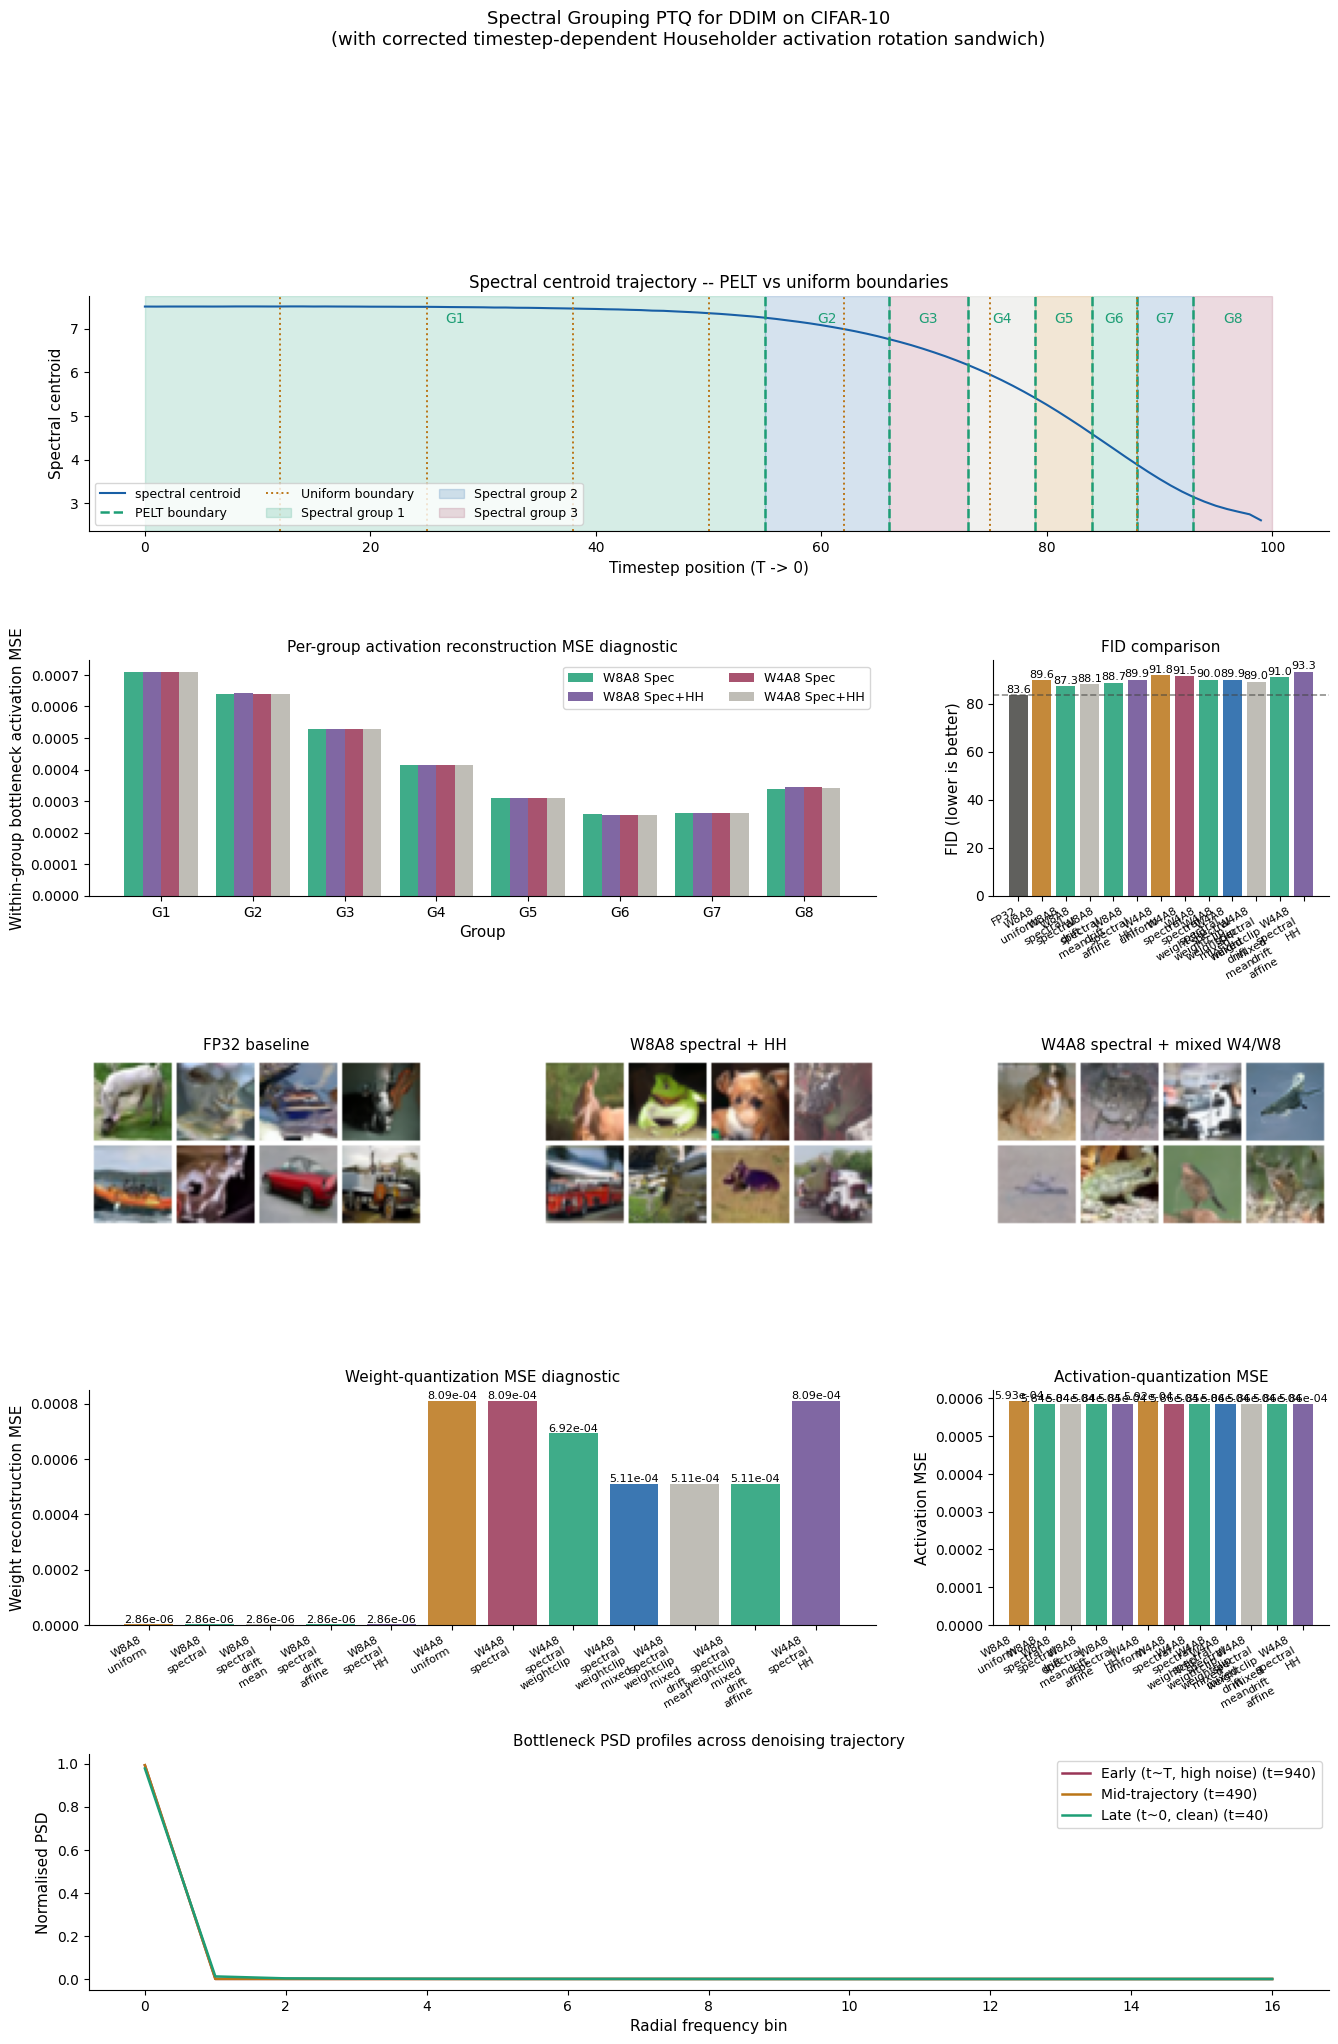

Figure saved as spectral_ptq_householder_results.png

Experiment                              FID      Act-MSE        W-MSE  HH layers
--------------------------------------------------------------------------------------------
FP32                                  83.61     0.000000     0.000000          0
W8A8_uniform                          89.64     0.000593     0.000003          0
W8A8_spectral                         87.26     0.000584     0.000003          0
W8A8_spectral_drift_mean              88.09     0.000584     0.000003          0
W8A8_spectral_drift_affine            88.75     0.000584     0.000003          0
W8A8_spectral_householder             89.89     0.000585     0.000003         12
W4A8_uniform                          91.82     0.000592     0.000809          0
W4A8_spectral                         91.53     0.000586     0.000809          0
W4A8_spectral_weightclip              90.03     0.000585     0.000692          0
W4A8_spectral_weightclip_mixed        89.88

In [32]:
fig = plt.figure(figsize=(16, 22))
gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.35)

COLORS = dict(
    fp32    = '#444441',
    spec    = '#1D9E75',
    unif    = '#BA7517',
    w8a8    = '#185FA5',
    w4a8    = '#993556',
    hh      = '#6A4C93',
    neutral = '#B4B2A9',
)


ax1 = fig.add_subplot(gs[0, :])
ts_x = list(range(len(sorted_ts)))
ax1.plot(ts_x, centroid_seq, color=COLORS['w8a8'], lw=1.5,
         label='spectral centroid')
for i, bp in enumerate(pelt_bkps[:-1]):
    ax1.axvline(bp, color=COLORS['spec'], lw=1.8, ls='--',
                label='PELT boundary' if i == 0 else '')
for i, bp in enumerate(uniform_bkps_idx[1:-1]):
    ax1.axvline(bp, color=COLORS['unif'], lw=1.4, ls=':',
                label='Uniform boundary' if i == 0 else '')
group_bounds = [0] + pelt_bkps
shades = [COLORS['spec']+'18', COLORS['w8a8']+'18',
          COLORS['w4a8']+'18', COLORS['neutral']+'18', COLORS['unif']+'18']
for i in range(len(group_bounds) - 1):
    ax1.axvspan(group_bounds[i], group_bounds[i+1],
                alpha=0.18, color=shades[i % len(shades)],
                label=f'Spectral group {i+1}' if i < 3 else '')
    mid = (group_bounds[i] + group_bounds[i+1]) / 2
    ax1.text(mid, centroid_seq.max() * 0.95, f'G{i+1}',
             ha='center', fontsize=10, color=COLORS['spec'], fontweight='500')
ax1.set_xlabel('Timestep position (T -> 0)', fontsize=11)
ax1.set_ylabel('Spectral centroid', fontsize=11)
ax1.set_title('Spectral centroid trajectory -- PELT vs uniform boundaries',
              fontsize=12, fontweight='500')
ax1.legend(fontsize=9, ncol=3)
ax1.spines[['top', 'right']].set_visible(False)


ax2 = fig.add_subplot(gs[1, :2])
n_g = n_groups
x   = np.arange(n_g)
series = []
if 'W8A8_spectral' in results:
    series.append(('W8A8 Spec', results['W8A8_spectral']['group_mses'], COLORS['spec']))
if 'W8A8_spectral_householder' in results:
    series.append(('W8A8 Spec+HH', results['W8A8_spectral_householder']['group_mses'], COLORS['hh']))
if 'W4A8_spectral' in results:
    series.append(('W4A8 Spec', results['W4A8_spectral']['group_mses'], COLORS['w4a8']))
if 'W4A8_spectral_householder' in results:
    series.append(('W4A8 Spec+HH', results['W4A8_spectral_householder']['group_mses'], COLORS['neutral']))
if not series:
    series.append(('No results yet', [0]*n_g, COLORS['neutral']))
bw = min(0.8 / len(series), 0.22)
for si, (label, vals, col) in enumerate(series):
    vals = (vals + [0]*n_g)[:n_g]
    offset = (si - (len(series)-1)/2) * bw
    ax2.bar(x + offset, vals, bw, label=label, color=col, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'G{i+1}' for i in range(n_g)])
ax2.set_xlabel('Group', fontsize=11)
ax2.set_ylabel('Within-group bottleneck activation MSE', fontsize=11)
ax2.set_title('Per-group activation reconstruction MSE diagnostic',
              fontsize=11, fontweight='500')
ax2.legend(fontsize=9, ncol=2)
ax2.spines[['top', 'right']].set_visible(False)


ax3 = fig.add_subplot(gs[1, 2])
preferred_order = [
    'FP32',
    'W8A8_uniform',
    'W8A8_spectral',
    'W8A8_spectral_drift_mean',
    'W8A8_spectral_drift_affine',
    'W8A8_spectral_householder',
    'W4A8_uniform',
    'W4A8_spectral',
    'W4A8_spectral_weightclip',
    'W4A8_spectral_weightclip_mixed',
    'W4A8_spectral_weightclip_mixed_drift_mean',
    'W4A8_spectral_weightclip_mixed_drift_affine',
    'W4A8_spectral_weightclip_drift_mean',
    'W4A8_spectral_weightclip_drift_affine',
    'W4A8_spectral_drift_mean',
    'W4A8_spectral_drift_affine',
    'W4A8_spectral_householder',
]
exp_keys = [k for k in preferred_order if k in results]
labels_fid = [k.replace('_', '\n').replace('householder', 'HH') for k in exp_keys]
fids = [results[k]['fid'] for k in exp_keys]
def color_for_key(k):
    if k == 'FP32': return COLORS['fp32']
    if 'drift' in k and 'affine' in k: return COLORS['spec']
    if 'drift' in k and 'mean' in k: return COLORS['neutral']
    if 'mixed' in k: return COLORS['w8a8']
    if 'weightclip' in k: return COLORS['spec']
    if 'householder' in k: return COLORS['hh']
    if 'uniform' in k: return COLORS['unif']
    if 'W4A8' in k: return COLORS['w4a8']
    return COLORS['spec']
bcolors = [color_for_key(k) for k in exp_keys]
bars = ax3.bar(range(len(exp_keys)), fids, color=bcolors, alpha=0.85, edgecolor='none')
if 'FP32' in results:
    ax3.axhline(results['FP32']['fid'], color=COLORS['fp32'], lw=1.2, ls='--', alpha=0.6)
for bar, f in zip(bars, fids):
    ax3.text(bar.get_x() + bar.get_width()/2, f + 0.3,
             f'{f:.1f}', ha='center', va='bottom', fontsize=8)
ax3.set_xticks(range(len(exp_keys)))
ax3.set_xticklabels(labels_fid, fontsize=8, rotation=30, ha='right')
ax3.set_ylabel('FID (lower is better)', fontsize=11)
ax3.set_title('FID comparison', fontsize=11, fontweight='500')
ax3.spines[['top', 'right']].set_visible(False)


n_show = 8
sample_sets = []
if 'fp32_imgs' in globals():
    sample_sets.append(('FP32 baseline', fp32_imgs[:n_show]))
if 'w8a8_s_hh_imgs' in globals():
    sample_sets.append(('W8A8 spectral + HH', w8a8_s_hh_imgs[:n_show]))
elif 'w8a8_s_imgs' in globals():
    sample_sets.append(('W8A8 spectral', w8a8_s_imgs[:n_show]))
if 'w4a8_s_mixed_imgs' in globals():
    sample_sets.append(('W4A8 spectral + mixed W4/W8', w4a8_s_mixed_imgs[:n_show]))
elif 'w4a8_s_wc_imgs' in globals():
    sample_sets.append(('W4A8 spectral + weight clipping', w4a8_s_wc_imgs[:n_show]))
elif 'w4a8_s_hh_imgs' in globals():
    sample_sets.append(('W4A8 spectral + HH', w4a8_s_hh_imgs[:n_show]))
elif 'w4a8_s_imgs' in globals():
    sample_sets.append(('W4A8 spectral', w4a8_s_imgs[:n_show]))
for col, (label, imgs) in enumerate(sample_sets[:3]):
    ax = fig.add_subplot(gs[2, col])
    grid = torchvision.utils.make_grid(
        imgs.float() / 255., nrow=4, padding=2, pad_value=1)
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(label, fontsize=11, fontweight='500')
    ax.axis('off')


metric_keys = [k for k in preferred_order if k in results and k != 'FP32']
metric_labels = [k.replace('_', '\n').replace('householder', 'HH') for k in metric_keys]
metric_colors = [color_for_key(k) for k in metric_keys]

ax_wmse = fig.add_subplot(gs[3, :2])
wmse_vals = [results[k].get('w_mse', 0.0) for k in metric_keys]
bars_w = ax_wmse.bar(range(len(metric_keys)), wmse_vals, color=metric_colors, alpha=0.85, edgecolor='none')
for bar, v in zip(bars_w, wmse_vals):
    ax_wmse.text(bar.get_x() + bar.get_width()/2, v,
                 f'{v:.2e}', ha='center', va='bottom', fontsize=8)
ax_wmse.set_xticks(range(len(metric_keys)))
ax_wmse.set_xticklabels(metric_labels, fontsize=8, rotation=30, ha='right')
ax_wmse.set_ylabel('Weight reconstruction MSE', fontsize=11)
ax_wmse.set_title('Weight-quantization MSE diagnostic',
                   fontsize=11, fontweight='500')
ax_wmse.spines[['top', 'right']].set_visible(False)

ax_amse = fig.add_subplot(gs[3, 2])
amse_vals = [results[k].get('act_mse', 0.0) for k in metric_keys]
bars_a = ax_amse.bar(range(len(metric_keys)), amse_vals, color=metric_colors, alpha=0.85, edgecolor='none')
for bar, v in zip(bars_a, amse_vals):
    ax_amse.text(bar.get_x() + bar.get_width()/2, v,
                 f'{v:.2e}', ha='center', va='bottom', fontsize=8)
ax_amse.set_xticks(range(len(metric_keys)))
ax_amse.set_xticklabels(metric_labels, fontsize=8, rotation=30, ha='right')
ax_amse.set_ylabel('Activation MSE', fontsize=11)
ax_amse.set_title('Activation-quantization MSE', fontsize=11, fontweight='500')
ax_amse.spines[['top', 'right']].set_visible(False)


ax5 = fig.add_subplot(gs[4, :])
sample_ts_psd = [
    sorted_ts[int(len(sorted_ts) * 0.05)],
    sorted_ts[int(len(sorted_ts) * 0.50)],
    sorted_ts[int(len(sorted_ts) * 0.95)],
]
ts_labels_psd = ['Early (t~T, high noise)', 'Mid-trajectory', 'Late (t~0, clean)']
ts_colors_psd = [COLORS['w4a8'], COLORS['unif'], COLORS['spec']]
for t_val, lbl, col in zip(sample_ts_psd, ts_labels_psd, ts_colors_psd):
    if t_val in psd_profiles:
        p = psd_profiles[t_val]
        ax5.plot(np.arange(len(p)), p / (p.sum() + 1e-8),
                 label=f'{lbl} (t={t_val})', color=col, lw=1.8)
ax5.set_xlabel('Radial frequency bin', fontsize=11)
ax5.set_ylabel('Normalised PSD', fontsize=11)
ax5.set_title('Bottleneck PSD profiles across denoising trajectory',
              fontsize=11, fontweight='500')
ax5.legend(fontsize=10)
ax5.spines[['top', 'right']].set_visible(False)

fig.suptitle('Spectral Grouping PTQ for DDIM on CIFAR-10\n'
             '(with corrected timestep-dependent Householder activation rotation sandwich)',
             fontsize=13, fontweight='500', y=1.01)
plt.savefig('spectral_ptq_householder_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as spectral_ptq_householder_results.png')


print('\n' + '='*92)
print(f"{'Experiment':<34} {'FID':>8} {'Act-MSE':>12} {'W-MSE':>12} {'HH layers':>10}")
print('-'*92)
for k in exp_keys:
    r = results[k]
    print(f"{k:<34} {r['fid']:>8.2f} "
          f"{r.get('act_mse', 0.0):>12.6f} "
          f"{r.get('w_mse',   0.0):>12.6f} "
          f"{r.get('n_householder_layers', 0):>10}")
print('='*92)


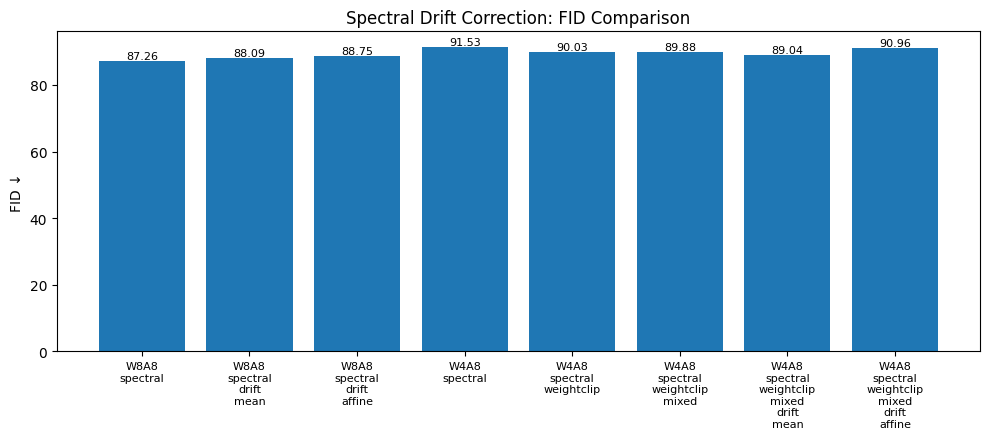


Drift-correction result table:
W8A8_spectral                                           FID=87.26
W8A8_spectral_drift_mean                                FID=88.09
W8A8_spectral_drift_affine                              FID=88.75
W4A8_spectral                                           FID=91.53
W4A8_spectral_weightclip                                FID=90.03
W4A8_spectral_weightclip_mixed                          FID=89.88
W4A8_spectral_weightclip_mixed_drift_mean               FID=89.04
W4A8_spectral_weightclip_mixed_drift_affine             FID=90.96


In [33]:
drift_order = [
    'W8A8_spectral',
    'W8A8_spectral_drift_mean',
    'W8A8_spectral_drift_affine',
    'W4A8_spectral',
    'W4A8_spectral_weightclip',
    'W4A8_spectral_weightclip_mixed',
    'W4A8_spectral_weightclip_mixed_drift_mean',
    'W4A8_spectral_weightclip_mixed_drift_affine',
    'W4A8_spectral_weightclip_drift_mean',
    'W4A8_spectral_weightclip_drift_affine',
    'W4A8_spectral_drift_mean',
    'W4A8_spectral_drift_affine',
]
drift_keys = [k for k in drift_order if k in results]
if drift_keys:
    plt.figure(figsize=(max(10, 0.8 * len(drift_keys)), 4.5))
    fids = [results[k]['fid'] for k in drift_keys]
    bars = plt.bar(range(len(drift_keys)), fids)
    plt.xticks(range(len(drift_keys)), [k.replace('_', '\n') for k in drift_keys], rotation=0, fontsize=8)
    plt.ylabel('FID ↓')
    plt.title('Spectral Drift Correction: FID Comparison')
    for i, v in enumerate(fids):
        plt.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('\nDrift-correction result table:')
    for k in drift_keys:
        print(f'{k:<55} FID={results[k]["fid"]:.2f}')
else:
    print('No drift-correction results found yet. Run the drift evaluation cell above first.')
